# Predicting Accident Severity on UK Road Traffic Data

Importing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import matplotlib.gridspec as gridspec

Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Filtering, Saving and Loading the datasets from 2011 onwards: vehicle, casualty and collision

# VEHICLE DATASET EXPLORATION

In [ ]:
# chunksize = 1000000
# output_path = "/content/drive/MyDrive/DA&M share/data/vehicle_2011_onwards.csv"
# first = True

# for chunk in pd.read_csv("/content/drive/MyDrive/DA&M share/data/dft-road-casualty-statistics-vehicle-1979-latest-published-year.csv", chunksize=chunksize, low_memory=False):
#     filtered = chunk[chunk["collision_year"] >= 2011]

#     filtered.to_csv(output_path, mode="a", index=False, header=first)
#     first = False

In [ ]:
# vehicle_df = pd.read_csv('/content/drive/MyDrive/DA&M share/data/vehicle_2011_onwards.csv', low_memory=False)
# print(vehicle_df.shape)
# vehicle_df.head()

In [ ]:
# vehicle_df_2024 = vehicle_df[vehicle_df['collision_year'] == 2024]
# vehicle_df_2024.to_csv('/content/drive/MyDrive/DA&M share/data/vehicle_2024.csv', index=False)
# print(vehicle_df_2024.shape)

# COLLISION DATASET EXPLORATION

In [ ]:
# chunksize = 1000000
# output_path = "/content/drive/MyDrive/DA&M share/data/collision_2011_onwards.csv"
# first = True

# for chunk in pd.read_csv("/content/drive/MyDrive/DA&M share/data/dft-road-casualty-statistics-collision-1979-latest-published-year.csv", chunksize=chunksize, low_memory=False):
#     filtered = chunk[chunk["collision_year"] >= 2011]

#     filtered.to_csv(output_path, mode="a", index=False, header=first)
#     first = False

In [ ]:
# collision_df = pd.read_csv('/content/drive/MyDrive/DA&M share/data/collision_2011_onwards.csv', low_memory=False)
# print(collision_df.shape)
# collision_df.head()

In [ ]:
# collision_df_2024 = collision_df[collision_df['collision_year'] == 2024]
# collision_df_2024.to_csv('/content/drive/MyDrive/DA&M share/data/collision_2024.csv', index=False)
# print(collision_df_2024.shape)

# CASUALTY DATASET EXPLORATION

In [ ]:
# chunksize = 1000000
# output_path = "/content/drive/MyDrive/DA&M share/data/casualty_2011_onwards.csv"
# first = True

# for chunk in pd.read_csv("/content/drive/MyDrive/DA&M share/data/dft-road-casualty-statistics-casualty-1979-latest-published-year.csv", chunksize=chunksize, low_memory=False):
#     filtered = chunk[chunk["collision_year"] >= 2011]

#     filtered.to_csv(output_path, mode="a", index=False, header=first)
#     first = False

In [ ]:
# casualty_df = pd.read_csv('/content/drive/MyDrive/DA&M share/data/casualty_2011_onwards.csv', low_memory=False)
# print(casualty_df.shape)
# casualty_df.head()

In [ ]:
# casualty_df_2024 = casualty_df[casualty_df['collision_year'] == 2024]
# casualty_df_2024.to_csv('/content/drive/MyDrive/DA&M share/data/casualty_2024.csv', index=False)
# print(casualty_df_2024.shape)

In [ ]:
vehicle_df_2024 = pd.read_csv('/content/drive/MyDrive/DA&M share/data/vehicle_2024.csv', low_memory=False)
print(vehicle_df_2024.shape)
collision_df_2024 = pd.read_csv('/content/drive/MyDrive/DA&M share/data/collision_2024.csv', low_memory=False)
print(collision_df_2024.shape)
casualty_df_2024 = pd.read_csv('/content/drive/MyDrive/DA&M share/data/casualty_2024.csv', low_memory=False)
print(casualty_df_2024.shape)


(183514, 32)
(100927, 44)
(128272, 23)


In [ ]:
vehicle_df_2024.isna().sum()

collision_index                              0
collision_year                               0
collision_ref_no                             0
vehicle_reference                            0
vehicle_type                                 0
towing_and_articulation                      0
vehicle_manoeuvre_historic                   0
vehicle_manoeuvre                            0
vehicle_direction_from                       0
vehicle_direction_to                         0
vehicle_location_restricted_lane_historic    0
vehicle_location_restricted_lane             0
junction_location                            0
skidding_and_overturning                     0
hit_object_in_carriageway                    0
vehicle_leaving_carriageway                  0
hit_object_off_carriageway                   0
first_point_of_impact                        0
vehicle_left_hand_drive                      0
journey_purpose_of_driver_historic           0
journey_purpose_of_driver                    0
sex_of_driver

In [ ]:
collision_df_2024.isna().sum()

collision_index                                     0
collision_year                                      0
collision_ref_no                                    0
location_easting_osgr                               0
location_northing_osgr                              0
longitude                                           0
latitude                                            0
police_force                                        0
collision_severity                                  0
number_of_vehicles                                  0
number_of_casualties                                0
date                                                0
day_of_week                                         0
time                                                0
local_authority_district                            0
local_authority_ons_district                        0
local_authority_highway                             0
local_authority_highway_current                     3
first_road_class            

In [ ]:
collision_df_2024.loc[collision_df_2024['local_authority_highway_current'].isna()]

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
947,2024991402765,2024,991402765,178532.0,719691.0,-5.58281,56.31770,99,3,2,...,-1,0,3,1,-1,-1,3,1,0.000000,1.000000
3182,202460Q125791,2024,60Q125791,254187.0,370960.0,-4.18517,53.21563,60,3,2,...,0,0,3,2,-1,-1,-1,0,0.054303,0.945697
93059,2024991470488,2024,991470488,312309.0,680743.0,-3.40804,56.01156,99,3,2,...,-1,0,3,1,-1,-1,3,1,0.000000,1.000000


In [ ]:
collision_df_2024.dropna(subset=['local_authority_highway_current'], inplace=True)
collision_df_2024.shape

(100924, 44)

In [ ]:
casualty_df_2024.isna().sum()

collision_index                       0
collision_year                        0
collision_ref_no                      0
vehicle_reference                     0
casualty_reference                    0
casualty_class                        0
sex_of_casualty                       0
age_of_casualty                       0
age_band_of_casualty                  0
casualty_severity                     0
pedestrian_location                   0
pedestrian_movement                   0
car_passenger                         0
bus_or_coach_passenger                0
pedestrian_road_maintenance_worker    0
casualty_type                         0
casualty_imd_decile                   0
lsoa_of_casualty                      0
enhanced_casualty_severity            0
casualty_injury_based                 0
casualty_adjusted_severity_serious    0
casualty_adjusted_severity_slight     0
casualty_distance_banding             0
dtype: int64

# Merging all datasets for 2024

In [ ]:
merge_2024 = pd.merge(vehicle_df_2024, collision_df_2024, on='collision_index', how='inner')
# merge_2024 = pd.merge(merge_2024, casualty_df_2024, on='collision_index', how='inner')
merge_2024 = pd.merge(merge_2024, casualty_df_2024, on=['collision_index', 'vehicle_reference'], how='inner')
print(merge_2024.shape)
merge_2024.head()

(128266, 96)


,collision_index,collision_year_x,collision_ref_no_x,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2024010526883,2024,010526883,1,9,0,11,11,3,7,...,0,0,9,3,E01024480,3,1,0.0,1.0,4
1,2024991446730,2024,991446730,1,3,0,-1,4,7,3,...,0,0,3,2,-1,3,1,0.0,1.0,2
2,2024461473110,2024,461473110,1,3,0,-1,19,1,5,...,0,0,3,7,E01024846,7,1,1.0,0.0,3
3,2024411459481,2024,411459481,2,4,-1,-1,3,4,8,...,0,0,4,3,E01023958,3,1,0.0,1.0,1
4,2024141466469,2024,141466469,1,9,0,-1,3,5,7,...,0,0,9,8,E01007890,3,1,0.0,1.0,1


In [ ]:
null_rows = merge_2024[merge_2024.isnull().any(axis=1)]
display(null_rows)

,collision_index,collision_year_x,collision_ref_no_x,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding


In [ ]:
missing_cols = null_rows.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
print(missing_cols)

Series([], dtype: int64)


In [ ]:
df_without_missing_vals = merge_2024.dropna()
print(df_without_missing_vals.shape)

(128266, 96)


# Removing all the rows having -1 in any of the columns because -1 basically is the value for missing or out of range, undefined data.

In [ ]:
# df_without_missing_vals = df_without_missing_vals[~(df_without_missing_vals == -1).any(axis=1)]
# print(f"Shape after removing rows with -1: {df_without_missing_vals.shape}")

# Can't remove all rows having -1 directly because then we are left with empty dataset, which implies each row has atleast one missing value.

# Let's analyse columns which have the most -1 present

In [ ]:
# This will show which columns are mostly missing data
missing_counts = (df_without_missing_vals == -1).sum()
total_rows = len(df_without_missing_vals)
missing_percentages = (missing_counts / total_rows) * 100

# Combine counts and percentages into a DataFrame for better display
missing_info = pd.DataFrame({
    'Count': missing_counts,
    'Percentage': missing_percentages
})

# Filter to see only columns that have at least one -1 and sort
print(missing_info[missing_info['Count'] > 0].sort_values(by='Count', ascending=False))

                                                   Count  Percentage
local_authority_district                          128266  100.000000
vehicle_manoeuvre_historic                         79732   62.161446
journey_purpose_of_driver_historic                 79108   61.674957
junction_detail_historic                           78216   60.979527
pedestrian_crossing_physical_facilities_historic   77858   60.700419
vehicle_location_restricted_lane_historic          77854   60.697301
carriageway_hazards_historic                       77850   60.694182
special_conditions_at_site                         77849   60.693403
pedestrian_crossing_human_control_historic         77848   60.692623
junction_control                                   55818   43.517378
enhanced_severity_collision                        50419   39.308156
engine_capacity_cc                                 37322   29.097345
age_of_vehicle                                     34949   27.247283
propulsion_code                   

In [ ]:
# Drop these columns from the DataFrame
# ['vehicle_manoeuvre_historic', 'vehicle_location_restricted_lane_historic', 'journey_purpose_of_driver_historic',
#  'local_authority_district', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic',
#  'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic']
dropped_features = ['vehicle_manoeuvre_historic', 'vehicle_location_restricted_lane_historic', 'journey_purpose_of_driver_historic',
 'local_authority_district', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic']

df_without_missing_vals = df_without_missing_vals.drop(columns=dropped_features)

print(f"Columns dropped due to more than 50% missing values and irrelevance in 2024: {dropped_features}")
print(f"New shape of the DataFrame after dropping columns: {df_without_missing_vals.shape}")

Columns dropped due to more than 50% missing values and irrelevance in 2024: ['vehicle_manoeuvre_historic', 'vehicle_location_restricted_lane_historic', 'journey_purpose_of_driver_historic', 'local_authority_district', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic']
New shape of the DataFrame after dropping columns: (128266, 88)


# Variables dropped
['vehicle_manoeuvre_historic', 'vehicle_location_restricted_lane_historic', 'journey_purpose_of_driver_historic',
'local_authority_district', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic',
'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic']

# Variables not considered further (clearly not useful):
{'casualty_reference',
 'collision_index',
 'collision_ref_no',
 'collision_ref_no_x',
 'collision_ref_no_y',
 'collision_year',
 'collision_year_x',
 'collision_year_y',
 'did_police_officer_attend_scene_of_accident',
 'local_authority_highway',
 'local_authority_highway_current',
 'local_authority_ons_district',
 'police_force',
 'propulsion_code',
 'vehicle_reference_x',
 'vehicle_reference_y'}

# Variables to be assessed further:

[    'vehicle_type', 'towing_and_articulation',
       'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver',
       'age_band_of_driver', 'engine_capacity_cc',
       'age_of_vehicle', 'generic_make_model', 'driver_imd_decile',
       'lsoa_of_driver', 'escooter_flag', 'driver_distance_banding',
       'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude',
       'collision_severity', 'number_of_vehicles', 'number_of_casualties',
       'date', 'day_of_week', 'time',
       'first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail', 'junction_control', 'second_road_class',
       'second_road_number', 'pedestrian_crossing', 'light_conditions',
       'weather_conditions', 'road_surface_conditions',
       'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area',
       'trunk_road_flag', 'lsoa_of_accident_location',
       'enhanced_severity_collision', 'collision_injury_based',
       'collision_adjusted_severity_serious',
       'collision_adjusted_severity_slight',
       'casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'casualty_severity', 'pedestrian_location',
       'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity',
       'casualty_injury_based', 'casualty_adjusted_severity_serious',
       'casualty_adjusted_severity_slight', 'casualty_distance_banding']

In [ ]:
selected_features1 = ['vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'engine_capacity_cc',
       'age_of_vehicle', 'generic_make_model', 'driver_imd_decile', 'lsoa_of_driver', 'escooter_flag', 'driver_distance_banding',
       'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'collision_severity', 'number_of_vehicles', 'number_of_casualties',
       'date', 'day_of_week', 'time','first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing', 'light_conditions',
       'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area','trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision', 'collision_injury_based',
       'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight', 'casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'casualty_severity', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity',
       'casualty_injury_based', 'casualty_adjusted_severity_serious', 'casualty_adjusted_severity_slight', 'casualty_distance_banding']

In [ ]:
len(selected_features1)

73

#### **Assessing Association with Cramer's V for Road Numbers**

Given that `first_road_number` and `second_road_number` are best treated as categorical variables, Pearson correlation is not appropriate. We will use Cramer's V to measure the strength of association between these two road numbers, and also their association with `collision_severity`.

### Interpretation of Cramer's V Scores

Cramer's V ranges from 0 to 1, where:
*   **0:** Indicates no association between the variables.
*   **1:** Indicates a perfect association between the variables.

Typically, values can be interpreted as follows:
*   **0.0 to 0.1:** Very weak or no association
*   **0.1 to 0.3:** Weak association
*   **0.3 to 0.5:** Moderate association
*   **> 0.5:** Strong association

The Cramer's V scores provide a more appropriate measure of association for these categorical features.

In [ ]:
find_features_df = df_without_missing_vals[selected_features1]
find_features_df['first_road_number'].value_counts()
# find_features_df['second_road_number'].value_counts()
# find_features_df[find_features_df['first_road_number']==-1]
# find_features_df[find_features_df['second_road_number']==-1]

first_road_number
0       49440
1        1495
6        1211
4         871
38        840
        ...  
840         1
544         1
5306        1
6092        1
9161        1
Name: count, Length: 3102, dtype: int64

In [ ]:
from scipy.stats import chi2_contingency

# Ensure df_without_missing_vals is prepared with 'Missing' values converted to np.nan for Cramer's V function
df_cramer_roads = df_without_missing_vals.copy()
# Replace '-1' with 'Missing' (string) before converting to category to treat them as a distinct category
df_cramer_roads['first_road_number'] = df_cramer_roads['first_road_number'].replace(-1, 'Missing').astype(str)
df_cramer_roads['second_road_number'] = df_cramer_roads['second_road_number'].replace(-1, 'Missing').astype(str)
df_cramer_roads['collision_severity'] = df_cramer_roads['collision_severity'].astype(str)

def calculate_cramers_v(df, col1, col2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])

    # Check if the matrix is too sparse or too small for chi2
    if confusion_matrix.empty or min(confusion_matrix.shape) < 2:
        return 0.0

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Bias-corrected Cramer's V calculation
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    # Guard against division by zero in bias correction
    if min((kcorr-1), (rcorr-1)) <= 0:
        v_score = np.sqrt(phi2) # Fallback to standard Cramer's V
    else:
        v_score = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    return v_score

# Calculate Cramer's V for first_road_number and second_road_number
cramer_v_roads = calculate_cramers_v(df_cramer_roads, 'first_road_number', 'second_road_number')
print(f"Cramer's V between first_road_number and second_road_number: {cramer_v_roads:.4f}")

# Calculate Cramer's V for first_road_number and collision_severity
cramer_v_first_road_severity = calculate_cramers_v(df_cramer_roads, 'first_road_number', 'collision_severity')
print(f"Cramer's V between first_road_number and collision_severity: {cramer_v_first_road_severity:.4f}")

# Calculate Cramer's V for second_road_number and collision_severity
cramer_v_second_road_severity = calculate_cramers_v(df_cramer_roads, 'second_road_number', 'collision_severity')
print(f"Cramer's V between second_road_number and collision_severity: {cramer_v_second_road_severity:.4f}")

Cramer's V between first_road_number and second_road_number: 0.2633
Cramer's V between first_road_number and collision_severity: 0.2148
Cramer's V between second_road_number and collision_severity: 0.1184


## Drop ['first_road_number', 'second_road_number'] - very high cardinality (2000+), and association with collision_severity is also very low

## Remaining features:
['vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'engine_capacity_cc',
       'age_of_vehicle', 'generic_make_model', 'driver_imd_decile', 'lsoa_of_driver', 'escooter_flag', 'driver_distance_banding',
       'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'collision_severity', 'number_of_vehicles', 'number_of_casualties',
       'date', 'day_of_week', 'time','first_road_class','road_type', 'speed_limit',
       'junction_detail', 'junction_control', 'second_road_class', 'pedestrian_crossing', 'light_conditions',
       'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area','trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision', 'collision_injury_based',
       'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight', 'casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'casualty_severity', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity',
       'casualty_injury_based', 'casualty_adjusted_severity_serious', 'casualty_adjusted_severity_slight', 'casualty_distance_banding']

# Assigning 'Unknowns' to unknown values shown by numeric data (9, 99, 3, 10, 2)

  ## Features where we have to replace 9 or 99 with 'Unknown':
  ['road_type','speed_limit','junction_detail','junction_control','second_road_class',
                      'pedestrian_crossing','weather_conditions','road_surface_conditions','special_conditions_at_site',
                      'carriageway_hazards','vehicle_type', 'towing_and_articulation','vehicle_manoeuvre','vehicle_direction_from','vehicle_direction_to',
                      'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning','hit_object_in_carriageway','vehicle_leaving_carriageway',
                      'hit_object_off_carriageway','first_point_of_impact','vehicle_left_hand_drive', 'sex_of_casualty', 'pedestrian_movement',
                      'car_passenger', 'bus_or_coach_passenger', 'casualty_type']

  ## Features having 'Unknown' values shown by different values
  * sex_of_driver: 3
  * pedestrian_location: 10
  * pedestrian_road_maintenance_worker: 2

In [ ]:
columnsWith9or99_to_process =  ['road_type','speed_limit','junction_detail','junction_control','second_road_class',
                      'pedestrian_crossing','weather_conditions','road_surface_conditions','special_conditions_at_site',
                      'carriageway_hazards','vehicle_type', 'towing_and_articulation','vehicle_manoeuvre','vehicle_direction_from','vehicle_direction_to',
                      'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning','hit_object_in_carriageway','vehicle_leaving_carriageway',
                      'hit_object_off_carriageway','first_point_of_impact','vehicle_left_hand_drive', 'sex_of_casualty', 'pedestrian_movement',
                      'car_passenger', 'bus_or_coach_passenger', 'casualty_type']
for col in columnsWith9or99_to_process:
   df_without_missing_vals[col] = df_without_missing_vals[col].replace([9, 99, '9', '99'], 'Unknown')

df_without_missing_vals['sex_of_driver'] = df_without_missing_vals['sex_of_driver'].astype(str).replace(['3',3], 'Unknown')
df_without_missing_vals['pedestrian_location'] = df_without_missing_vals['pedestrian_location'].replace(['10',10], 'Unknown')
df_without_missing_vals['pedestrian_road_maintenance_worker'] = df_without_missing_vals['pedestrian_road_maintenance_worker'].replace(['2',2], 'Unknown')
df_without_missing_vals.head()


,collision_index,collision_year_x,collision_ref_no_x,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2024010526883,2024,010526883,1,Unknown,0,11,3,7,0,...,0,0,Unknown,3,E01024480,3,1,0.0,1.0,4
1,2024991446730,2024,991446730,1,3,0,4,7,3,0,...,0,0,3,2,-1,3,1,0.0,1.0,2
2,2024461473110,2024,461473110,1,3,0,19,1,5,0,...,0,0,3,7,E01024846,7,1,1.0,0.0,3
3,2024411459481,2024,411459481,2,4,-1,3,4,8,0,...,0,0,4,3,E01023958,3,1,0.0,1.0,1
4,2024141466469,2024,141466469,1,Unknown,0,3,5,7,0,...,0,0,Unknown,8,E01007890,3,1,0.0,1.0,1


# Assigning Nan in place of -1 for missing values

* Col not in 2024 data:

['enhanced_collision_severity']

* Col already dropped:

['local_authority_district', 'junction_detail_historic', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'carriageway_hazards_historic', 'did_police_officer_attend_scene_of_collision', 'vehicle_manoeuvre_historic', 'vehicle_location_restricted_lane_historic', 'journey_purpose_of_driver_historic']

In [ ]:
cols_with_missing_vals = ['local_authority_ons_district','local_authority_highway','first_road_class',
'road_type','speed_limit','junction_detail','junction_control','second_road_class','pedestrian_crossing','light_conditions','weather_conditions','road_surface_conditions','special_conditions_at_site',
'carriageway_hazards','urban_or_rural_area','did_police_officer_attend_scene_of_accident',
'trunk_road_flag','vehicle_type','towing_and_articulation','vehicle_manoeuvre','vehicle_direction_from','vehicle_direction_to',
'vehicle_location_restricted_lane','junction_location','skidding_and_overturning','hit_object_in_carriageway','vehicle_leaving_carriageway','hit_object_off_carriageway',
'first_point_of_impact','vehicle_left_hand_drive','journey_purpose_of_driver','sex_of_driver','age_of_driver','age_band_of_driver',
'engine_capacity_cc','generic_make_model','driver_imd_decile','driver_distance_banding','sex_of_casualty','age_of_casualty','age_band_of_casualty','enhanced_casualty_severity',
'pedestrian_location','pedestrian_movement','car_passenger','bus_or_coach_passenger','pedestrian_road_maintenance_worker','casualty_type','casualty_imd_decile','casualty_distance_banding'
]

for col in cols_with_missing_vals:
    df_without_missing_vals[col] = df_without_missing_vals[col].replace(['-1',-1], np.nan)


In [ ]:
selected_features2 = ['vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane',
                      'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
                      'first_point_of_impact', 'vehicle_left_hand_drive', 'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver',
                      'engine_capacity_cc', 'age_of_vehicle', 'generic_make_model', 'driver_imd_decile', 'lsoa_of_driver', 'escooter_flag', 'driver_distance_banding',
                      'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'collision_severity', 'number_of_vehicles', 'number_of_casualties',
                      'date', 'day_of_week', 'time','first_road_class','road_type', 'speed_limit', 'junction_detail', 'junction_control', 'second_road_class',
                      'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards',
                      'urban_or_rural_area','trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision', 'collision_injury_based',
                      'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight', 'casualty_class', 'sex_of_casualty', 'age_of_casualty',
                      'age_band_of_casualty', 'casualty_severity', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger',
                      'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity',
                      'casualty_injury_based', 'casualty_adjusted_severity_serious', 'casualty_adjusted_severity_slight', 'casualty_distance_banding']

len(selected_features2)

71

In [ ]:
find_features_df = df_without_missing_vals[selected_features2]

# Counting unique values per feature
count_unique_vals = dict()
for cols in selected_features2:
    count_unique_vals[cols] = len(find_features_df[cols].value_counts())
count_unique_df = pd.DataFrame(count_unique_vals, index=['Count']).T
count_unique_df.sort_values(by='Count', ascending=False, inplace=True)


In [ ]:
count_unique_df.head(50)

,Count
longitude,87346
location_northing_osgr,83248
location_easting_osgr,82636
latitude,81909
lsoa_of_driver,31088
lsoa_of_casualty,30900
lsoa_of_accident_location,27200
collision_adjusted_severity_serious,17158
collision_adjusted_severity_slight,17158
casualty_adjusted_severity_slight,13146


# Features having high cardinality or not relevant for predicting collision severity

['lsoa_of_accident_location', 'lsoa_of_casualty', 'lsoa_of_driver', 'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight',
'casualty_adjusted_severity_slight', 'casualty_adjusted_severity_serious', 'engine_capacity_cc', 'generic_make_model', 'driver_imd_decile', 'enhanced_severity_collision', 'enhanced_casualty_severity', 'car_passenger', 'casualty_severity', 'escooter_flag', 'collision_injury_based', 'casualty_injury_based'
]

In [ ]:
numeric_cols = ['longitude', 'latitude', 'location_easting_osgr', 'location_northing_osgr', 'number_of_casualties', 'number_of_vehicles', 'speed_limit']
date_time_cols = ['date', 'time', 'day_of_week']
age_cols = ['age_of_vehicle', 'age_of_driver', 'age_of_casualty', 'age_band_of_driver', 'age_band_of_casualty']
categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'pedestrian_location', 'vehicle_direction_from', 'junction_location', 'pedestrian_movement', 'vehicle_direction_to', 'vehicle_leaving_carriageway',
                    'casualty_imd_decile', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site', 'vehicle_location_restricted_lane', 'towing_and_articulation',
                    'second_road_class', 'junction_detail', 'skidding_and_overturning', 'bus_or_coach_passenger', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'vehicle_left_hand_drive', 'pedestrian_road_maintenance_worker', 'sex_of_casualty', 'trunk_road_flag',
                    'urban_or_rural_area']
target_col = ['collision_severity']

len(numeric_cols) + len(date_time_cols) + len(age_cols) + len(categorical_cols) + len(target_col) + len(['lsoa_of_accident_location', 'lsoa_of_casualty', 'lsoa_of_driver', 'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight', 'casualty_adjusted_severity_slight', 'casualty_adjusted_severity_serious', 'engine_capacity_cc', 'generic_make_model', 'driver_imd_decile', 'enhanced_severity_collision', 'enhanced_casualty_severity', 'car_passenger', 'casualty_severity', 'escooter_flag', 'collision_injury_based', 'casualty_injury_based' ])

71

In [ ]:
find_features_df[numeric_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128266 entries, 0 to 128265
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   longitude               128266 non-null  float64
 1   latitude                128266 non-null  float64
 2   location_easting_osgr   128266 non-null  float64
 3   location_northing_osgr  128266 non-null  float64
 4   number_of_casualties    128266 non-null  int64  
 5   number_of_vehicles      128266 non-null  int64  
 6   speed_limit             128263 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 6.9 MB


In [ ]:
find_features_df[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128266 entries, 0 to 128265
Data columns (total 38 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   casualty_type                       127146 non-null  object 
 1   vehicle_type                        126923 non-null  object 
 2   vehicle_manoeuvre                   124528 non-null  object 
 3   carriageway_hazards                 127762 non-null  object 
 4   hit_object_off_carriageway          128047 non-null  object 
 5   hit_object_in_carriageway           126511 non-null  object 
 6   pedestrian_location                 128260 non-null  object 
 7   vehicle_direction_from              124975 non-null  object 
 8   junction_location                   127485 non-null  object 
 9   pedestrian_movement                 128259 non-null  object 
 10  vehicle_direction_to                124958 non-null  object 
 11  vehicle_leaving_carriagewa

# Converting all categorical features' datatype to object

In [ ]:
# Converting all categorical features' datatype to object
for col in categorical_cols:
      # Check if the column is of integer or float type
      if pd.api.types.is_integer_dtype(df_without_missing_vals[col]) or pd.api.types.is_float_dtype(df_without_missing_vals[col]):
          df_without_missing_vals[col] = df_without_missing_vals[col].astype('object')
          print(f"Converted column '{col}' to object type.")

print("\nData types after conversion:")
df_without_missing_vals[categorical_cols].info()

Converted column 'casualty_imd_decile' to object type.
Converted column 'second_road_class' to object type.
Converted column 'journey_purpose_of_driver' to object type.
Converted column 'first_road_class' to object type.
Converted column 'driver_distance_banding' to object type.
Converted column 'casualty_distance_banding' to object type.
Converted column 'light_conditions' to object type.
Converted column 'casualty_class' to object type.
Converted column 'trunk_road_flag' to object type.
Converted column 'urban_or_rural_area' to object type.

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128266 entries, 0 to 128265
Data columns (total 38 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   casualty_type                       127146 non-null  object
 1   vehicle_type                        126923 non-null  object
 2   vehicle_manoeuvre                   124528 no

Step 1: Drop before anything else
Semantic leakage / derived columns:

* **casualty_class** -> this is derived from severity (e.g. "fatal", "serious"), so it leaks the target. Hence we will drop it.
* **casualty_imd_decile** -> deprivation index of the casualty, not directly causal to collision outcome. Borderline (skip unless doing inequality analysis)



In [ ]:
# Helper functions
def cramers_v(x, y):
    tbl = pd.crosstab(x.astype(str), y.astype(str))
    chi2 = chi2_contingency(tbl)[0]
    n = tbl.values.sum()
    r, k = tbl.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def section(title):
    print("\n" + "═" * 70)
    print(f"  {title}")
    print("═" * 70)

* Coordinate redundancy -> **location_easting_osgr** and **location_northing_osgr** are just re-projections of latitude/longitude. Keep only **lat/lon**.



 <!-- or better yet engineer a single urban_rural indicator (which we already have as urban_or_rural_area). -->

In [ ]:
df = df_without_missing_vals

section("1. COORDINATE DUPLICATES — correlation with lat/lon")

coord_pairs = [
    ('latitude',  'location_northing_osgr'),
    ('longitude', 'location_easting_osgr'),
]
for a, b in coord_pairs:
    corr = df[[a, b]].corr().iloc[0, 1]
    verdict = "DROP ✓" if abs(corr) > 0.99 else "KEEP — not as correlated as expected"
    print(f"  {a:30s} ↔ {b:30s}  r = {corr:.6f}  → {verdict}")


══════════════════════════════════════════════════════════════════════
  1. COORDINATE DUPLICATES — correlation with lat/lon
══════════════════════════════════════════════════════════════════════
  latitude                       ↔ location_northing_osgr          r = 0.999968  → DROP ✓
  longitude                      ↔ location_easting_osgr           r = 0.999427  → DROP ✓


In [ ]:
# Dropped ['location_easting_osgr','location_northing_osgr']
numeric_cols = ['longitude', 'latitude', 'number_of_casualties', 'number_of_vehicles', 'speed_limit']

* Age band vs raw age -> **age_band_of_driver** and **age_band_of_casualty** are binned versions of age_of_driver and age_of_casualty. Keep the raw numeric versions as they carry more information and you can always bin later.

In [ ]:
section("2. AGE BANDS — are they just bucketed raw age?")

age_pairs = [
    ('age_of_driver',   'age_band_of_driver'),
    ('age_of_casualty', 'age_band_of_casualty'),
]
for raw, band in age_pairs:
    # Show the band boundaries vs raw age range per band
    grp = df.groupby(band)[raw].agg(['min', 'max', 'mean', 'count'])
    print(f"\n  {raw} vs {band}:")
    print(grp.to_string())
    corr = df[[raw, band]].corr().iloc[0, 1]
    verdict = "DROP band ✓" if abs(corr) > 0.9 else "KEEP — weaker correlation than expected"
    print(f"  Pearson r = {corr:.4f}  → {verdict}")


══════════════════════════════════════════════════════════════════════
  2. AGE BANDS — are they just bucketed raw age?
══════════════════════════════════════════════════════════════════════

  age_of_driver vs age_band_of_driver:
                     min   max       mean  count
age_band_of_driver                              
1.0                  1.0   5.0   4.000000     36
2.0                  6.0  10.0   8.736413    368
3.0                 11.0  15.0  13.307911   1757
4.0                 16.0  20.0  18.427478  11762
5.0                 21.0  25.0  23.061885  13315
6.0                 26.0  35.0  30.514835  27199
7.0                 36.0  45.0  40.295993  23433
8.0                 46.0  55.0  50.478482  17497
9.0                 56.0  65.0  60.070444  13997
10.0                66.0  75.0  70.176723   6530
11.0                76.0  99.0  81.299576   5184
  Pearson r = 0.9798  → DROP band ✓



  age_of_casualty vs age_band_of_casualty:
                       min   max       mean  count
age_band_of_casualty                              
1.0                    0.0   5.0   3.124691   2021
2.0                    6.0  10.0   8.184314   3315
3.0                   11.0  15.0  12.963035   6195
4.0                   16.0  20.0  18.215503  13494
5.0                   21.0  25.0  23.021635  13358
6.0                   26.0  35.0  30.411588  25336
7.0                   36.0  45.0  40.276498  20228
8.0                   46.0  55.0  50.533342  15626
9.0                   56.0  65.0  60.129294  13071
10.0                  66.0  75.0  70.232454   6939
11.0                  76.0  99.0  81.674604   6131
  Pearson r = 0.9766  → DROP band ✓


In [ ]:
# Dropped ['age_band_of_driver', 'age_band_of_casualty']
age_cols = ['age_of_vehicle', 'age_of_driver', 'age_of_casualty']

# Keep all three: ['junction_detail', 'junction_location', 'junction_control']
Both ('junction_location', 'junction_control') flagged as REVIEW because V < 0.5
=> moderate but not strong overlap

In [ ]:
section("3. JUNCTION COLLINEARITY: Cramér's V with junction_detail")

junction_cols = ['junction_control', 'junction_location']
for col in junction_cols:
    v = cramers_v(df['junction_detail'], df[col])
    verdict = "DROP ✓" if v > 0.5 else f"REVIEW — V only {v:.3f}, may have independent signal"
    print(f"  junction_detail ↔ {col:25s}  V = {v:.3f}  → {verdict}")

# Also show cross-tabs to understand the overlap qualitatively
print("\n  junction_detail × junction_control value counts (top combos):")
ct = pd.crosstab(df['junction_detail'], df['junction_control'])
print(ct.to_string())

print("\n  junction_detail × junction_location value counts (top combos):")
ct2 = pd.crosstab(df['junction_detail'], df['junction_location'])
print(ct2.to_string())


══════════════════════════════════════════════════════════════════════
  3. JUNCTION COLLINEARITY: Cramér's V with junction_detail
══════════════════════════════════════════════════════════════════════
  junction_detail ↔ junction_control           V = 0.466  → REVIEW — V only 0.466, may have independent signal
  junction_detail ↔ junction_location          V = 0.399  → REVIEW — V only 0.399, may have independent signal

  junction_detail × junction_control value counts (top combos):
junction_control    1     2    3      4  Unknown
junction_detail                                 
0                  37   941   22   4383        2
13                187  4006  328  29652       51
16                 75  5583  352   6447       14
17                 33  1073   27    963        0
18                 16    48   10   2378       61
19                 98  1254   80   6074      159
Unknown             0     0    0      2        1

  junction_detail × junction_location value counts (top combos):
jun

 # Drop trunk_road_flag: It's 90% one value (Non-trunk) and its association with Collision Severity is also negligible: 0.078

In [ ]:
section("4. ROAD CLASS & TRUNK FLAG — redundancy check")

road_pairs = [
    ('first_road_class', 'second_road_class'),
    ('first_road_class', 'trunk_road_flag'),
    ('road_type',        'trunk_road_flag'),
    ('road_type',        'first_road_class'),
    ('second_road_class', 'trunk_road_flag'),
    ('road_type', 'second_road_class'),
]
for a, b in road_pairs:
    v = cramers_v(df[a], df[b])
    verdict = "DROP ✓" if v > 0.5 else f"REVIEW — V = {v:.3f}"
    print(f"  {a:25s} ↔ {b:25s}  V = {v:.3f}  → {verdict}")

# Distribution of second_road_class — how often is it "Not at junction"?
print("\n  second_road_class distribution (proportion):")
print(df['second_road_class'].value_counts(normalize=True).round(3).to_string())

print("\n  trunk_road_flag distribution (proportion):")
print(df['trunk_road_flag'].value_counts(normalize=True).round(3).to_string())

trunk_road_flag_with_collision_severity = cramers_v(df['trunk_road_flag'], df['collision_severity'])
print("Association of trunk road flag with Collision Severity: ", trunk_road_flag_with_collision_severity)


══════════════════════════════════════════════════════════════════════
  4. ROAD CLASS & TRUNK FLAG — redundancy check
══════════════════════════════════════════════════════════════════════
  first_road_class          ↔ second_road_class          V = 0.267  → REVIEW — V = 0.267
  first_road_class          ↔ trunk_road_flag            V = 0.464  → REVIEW — V = 0.464
  road_type                 ↔ trunk_road_flag            V = 0.332  → REVIEW — V = 0.332
  road_type                 ↔ first_road_class           V = 0.237  → REVIEW — V = 0.237
  second_road_class         ↔ trunk_road_flag            V = 0.270  → REVIEW — V = 0.270
  road_type                 ↔ second_road_class          V = 0.196  → REVIEW — V = 0.196

  second_road_class distribution (proportion):
second_road_class
6.0    0.629
0.0    0.146
3.0    0.133
4.0    0.051
5.0    0.030
1.0    0.010
2.0    0.001

  trunk_road_flag distribution (proportion):
trunk_road_flag
2.0    0.918
1.0    0.082
Association of trunk road flag

In [ ]:
# Dropped trunk_road_flag
categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'pedestrian_location', 'vehicle_direction_from', 'junction_location', 'pedestrian_movement', 'vehicle_direction_to', 'vehicle_leaving_carriageway',
                    'casualty_imd_decile', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site', 'vehicle_location_restricted_lane', 'towing_and_articulation',
                    'second_road_class', 'junction_detail', 'skidding_and_overturning', 'bus_or_coach_passenger', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'vehicle_left_hand_drive', 'pedestrian_road_maintenance_worker', 'sex_of_casualty',
                    'urban_or_rural_area']
len(categorical_cols)

37

# Vehicle Direction (checking collinearity btw ['vehicle_direction_from', 'vehicle_direction_to'] and their association with collision severity)
V = 0.096 and 0.095 with severity means compass direction explains almost nothing about how severe a crash is. Hence, drop both ('vehicle_direction_from', 'vehicle_direction_to')

High collinearity is also obderved between both -> 0.807

In [ ]:
section("5. VEHICLE DIRECTION — any association with collision_severity?")

for col in ['vehicle_direction_from', 'vehicle_direction_to']:
    v = cramers_v(df[col], df['collision_severity'])
    print(f"  {col:30s} ↔ collision_severity  V = {v:.3f}")
    print(f"  Distribution:")
    print(f"  {df[col].value_counts(normalize=True).round(3).to_string()}\n")
    verdict = "DROP ✓" if v < 0.1 else f"REVIEW — V = {v:.3f}, some association exists"
    print(f"  → {verdict}")

# Collinearity between the two direction cols themselves
v_dir = cramers_v(df['vehicle_direction_from'], df['vehicle_direction_to'])
print(f"\n  vehicle_direction_from ↔ vehicle_direction_to  V = {v_dir:.3f}")
print(f"  → {'Highly collinear with each other too ✓' if v_dir > 0.7 else 'Weaker collinearity'}")


══════════════════════════════════════════════════════════════════════
  5. VEHICLE DIRECTION — any association with collision_severity?
══════════════════════════════════════════════════════════════════════
  vehicle_direction_from         ↔ collision_severity  V = 0.098
  Distribution:
  vehicle_direction_from
1          0.163
5          0.156
3          0.141
7          0.135
2          0.084
6          0.082
4          0.078
8          0.078
Unknown    0.071
0          0.013

  → DROP ✓
  vehicle_direction_to           ↔ collision_severity  V = 0.098
  Distribution:
  vehicle_direction_to
1          0.157
5          0.154
7          0.140
3          0.139
2          0.087
6          0.085
4          0.081
8          0.076
Unknown    0.071
0          0.011

  → DROP ✓

  vehicle_direction_from ↔ vehicle_direction_to  V = 0.817
  → Highly collinear with each other too ✓


In [ ]:
# Dropped 'vehicle_direction_to' and 'vehicle_direction_from'

categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'pedestrian_location', 'junction_location', 'pedestrian_movement', 'vehicle_leaving_carriageway',
                    'casualty_imd_decile', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site', 'vehicle_location_restricted_lane', 'towing_and_articulation',
                    'second_road_class', 'junction_detail', 'skidding_and_overturning', 'bus_or_coach_passenger', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'vehicle_left_hand_drive', 'pedestrian_road_maintenance_worker', 'sex_of_casualty',
                    'urban_or_rural_area']

len(categorical_cols)

35

* **towing_and_articulation**: 96.6% is code 0 ("No tow"), Cramer's V with severity = 0.057 Hence drop: almost no variation and almost no severity signal.

* **vehicle_left_hand_drive**: 86.2% is code 1 ("No").

  The remaining 13.8% is split between "Unknown" (12.3%) and "Yes/LHD" (1.5%). The problem is that most of that variation is "Unknown". Cramer's V = 0.079 with collision severity is very weak. Hence, Drop it. The small LHD proportion (1.5%) and weak severity signal don't justify keeping it.

In [ ]:
section("6. NEAR-ZERO VARIANCE — dominant category check")

low_var_cols = ['towing_and_articulation', 'vehicle_left_hand_drive']
for col in low_var_cols:
    vc = df[col].value_counts(normalize=True)
    dominant = vc.iloc[0]
    n_unique = df[col].nunique()
    verdict = "DROP ✓" if dominant > 0.90 else f"REVIEW — dominant = {dominant:.1%}, may have signal"
    print(f"\n  {col}:")
    print(f"  {vc.round(3).to_string()}")
    print(f"  Dominant category: {dominant:.1%}  Unique values: {n_unique}  → {verdict}")

    # Even if low variance, does it associate with severity?
    v = cramers_v(df[col], df['collision_severity'])
    print(f"  Cramér's V with collision_severity = {v:.3f}")


══════════════════════════════════════════════════════════════════════
  6. NEAR-ZERO VARIANCE — dominant category check
══════════════════════════════════════════════════════════════════════

  towing_and_articulation:
  towing_and_articulation
0          0.967
Unknown    0.027
1          0.002
4          0.002
5          0.001
3          0.001
2          0.000
  Dominant category: 96.7%  Unique values: 7  → DROP ✓
  Cramér's V with collision_severity = 0.060

  vehicle_left_hand_drive:
  vehicle_left_hand_drive
1          0.894
Unknown    0.094
2          0.012
  Dominant category: 89.4%  Unique values: 3  → REVIEW — dominant = 89.4%, may have signal
  Cramér's V with collision_severity = 0.067


In [ ]:
# Dropped 'towing_and_articulation' and 'vehicle_left_hand_drive'
categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'pedestrian_location', 'junction_location', 'pedestrian_movement', 'vehicle_leaving_carriageway',
                    'casualty_imd_decile', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site', 'vehicle_location_restricted_lane',
                    'second_road_class', 'junction_detail', 'skidding_and_overturning', 'bus_or_coach_passenger', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'pedestrian_road_maintenance_worker', 'sex_of_casualty',
                    'urban_or_rural_area']
len(categorical_cols)

33

* **casualty_imd_decile**: Missing 13.1%, fairly evenly spread across deciles 1–10 (each ~7–12%), Cramer's V = 0.027 with collision severity. The near-uniform distribution and near-zero V confirm this is capturing social deprivation geography, not collision severity mechanics. Hence, drop confirmed.

* **casualty_distance_banding**: Missing 13.1%, 54.3% in category 1 (within 5km of home), V = 0.051. Flagged REVIEW. The V is low but not zero, people driving far from home may be less familiar with roads. Decision: Keep

Association: casualty_imd_decile ↔ casualty_distance_banding  V = 0.451 (Moderate) - Let's keep **casualty_distance_banding** for now.

* **bus_or_coach_passenger**: 98.7% code 0 ("Not a bus passenger"), V = 0.012. Hence drop, essentially constant.

* **pedestrian_road_maintenance_worker**: 100% code 0 in data. Literally zero variance. Hence, drop.

In [ ]:
section("7. SPARSE / EQUITY VARIABLES — missingness and severity association")

sparse_cols = [
    'casualty_imd_decile',
    'casualty_distance_banding',
    'bus_or_coach_passenger',
    'pedestrian_road_maintenance_worker',
]
for col in sparse_cols:
    missing_pct = df[col].isnull().mean()
    vc = df[col].value_counts(normalize=True)
    dominant = vc.iloc[0]
    v = cramers_v(df[col].fillna(-999).astype(str), df['collision_severity'].astype(str))

    print(f"\n  {col}:")
    print(f"  Missing: {missing_pct:.1%}  |  Dominant category: {dominant:.1%}  |  V with severity: {v:.3f}")
    print(f"  Distribution:\n  {vc.round(3).to_string()}")

    if v < 0.05 or dominant > 0.92:
        print(f"  → DROP ✓  (weak severity signal or near-zero variance)")
    elif missing_pct > 0.30:
        print(f"  → REVIEW — high missingness but some severity signal (V={v:.3f})")
    else:
        print(f"  → REVIEW — V={v:.3f}, consider keeping")

x = cramers_v(df['casualty_imd_decile'], df['casualty_distance_banding'])
print(f"\n  casualty_imd_decile ↔ casualty_distance_banding  V = {x:.3f}")


══════════════════════════════════════════════════════════════════════
  7. SPARSE / EQUITY VARIABLES — missingness and severity association
══════════════════════════════════════════════════════════════════════

  casualty_imd_decile:
  Missing: 13.5%  |  Dominant category: 12.1%  |  V with severity: 0.029
  Distribution:
  casualty_imd_decile
2.0     0.121
1.0     0.117
3.0     0.116
4.0     0.112
5.0     0.106
6.0     0.101
7.0     0.094
8.0     0.087
9.0     0.078
10.0    0.068
  → DROP ✓  (weak severity signal or near-zero variance)

  casualty_distance_banding:
  Missing: 13.5%  |  Dominant category: 56.5%  |  V with severity: 0.042
  Distribution:
  casualty_distance_banding
1.0    0.565
2.0    0.156
4.0    0.123
3.0    0.121
5.0    0.035
  → DROP ✓  (weak severity signal or near-zero variance)

  bus_or_coach_passenger:
  Missing: 0.0%  |  Dominant category: 98.4%  |  V with severity: 0.013
  Distribution:
  bus_or_coach_passenger
0          0.984
4          0.010
3          0

C:\Users\13643\AppData\Local\Temp\ipykernel_3444\3072305702.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  v = cramers_v(df[col].fillna(-999).astype(str), df['collision_severity'].astype(str))
C:\Users\13643\AppData\Local\Temp\ipykernel_3444\3072305702.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  v = cramers_v(df[col].fillna(-999).astype(str), df['collision_severity'].astype(str))



  pedestrian_road_maintenance_worker:
  Missing: 8.8%  |  Dominant category: 100.0%  |  V with severity: 0.041
  Distribution:
  pedestrian_road_maintenance_worker
0          1.0
1          0.0
Unknown    0.0
  → DROP ✓  (weak severity signal or near-zero variance)

  casualty_imd_decile ↔ casualty_distance_banding  V = 0.451


In [ ]:
# Dropped 'casualty_imd_decile', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker'
categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'pedestrian_location', 'junction_location', 'pedestrian_movement', 'vehicle_leaving_carriageway',
                    'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site', 'vehicle_location_restricted_lane',
                    'second_road_class', 'junction_detail', 'skidding_and_overturning', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'sex_of_casualty',
                    'urban_or_rural_area']

len(categorical_cols)

30

* DROP pedestrian_location — collinear with pedestrian_movement (V=0.531) and adds almost no severity signal beyond it (0.040 vs 0.038)

* KEEP pedestrian_movement — describes pedestrian behaviour

* KEEP pedestrian_crossing — independent of movement (V=0.056), highest severity signal (V=0.075), and captures road infrastructure which is a different causal dimension entirely

In [ ]:
section("8. PEDESTRIAN COLLINEARITY — vs pedestrian_movement")

ped_cols = ['pedestrian_location', 'pedestrian_crossing']
for col in ped_cols:
    v_mov = cramers_v(df['pedestrian_movement'], df[col])
    v_sev = cramers_v(df[col], df['collision_severity'])
    v_mov_sev = cramers_v(df['pedestrian_movement'], df['collision_severity'])

    print(f"\n  {col}:")
    print(f"  V with pedestrian_movement = {v_mov:.3f}")
    print(f"  V with collision_severity  = {v_sev:.3f}  (pedestrian_movement has V = {v_mov_sev:.3f})")

    if v_mov > 0.6 and v_sev <= v_mov_sev:
        print(f"  → DROP ✓  (collinear with movement, no additional severity signal)")
    elif v_sev > v_mov_sev:
        print(f"  → KEEP — adds severity signal beyond pedestrian_movement (V={v_sev:.3f} > {v_mov_sev:.3f})")
    else:
        print(f"  → REVIEW — V={v_mov:.3f} with movement, V={v_sev:.3f} with severity")

locAssociationCross = cramers_v(df['pedestrian_location'], df['pedestrian_crossing'])
print(f"\n  pedestrian_location ↔ pedestrian_crossing  V = {locAssociationCross:.3f}")

locAssociationMovement = cramers_v(df['pedestrian_location'], df['pedestrian_movement'])
print(f"\n  pedestrian_location ↔ pedestrian_movement  V = {locAssociationMovement:.3f}")

crossAssociationMovement = cramers_v(df['pedestrian_crossing'], df['pedestrian_movement'])
print(f"\n  pedestrian_crossing ↔ pedestrian_movement  V = {crossAssociationMovement:.3f}")


══════════════════════════════════════════════════════════════════════
  8. PEDESTRIAN COLLINEARITY — vs pedestrian_movement
══════════════════════════════════════════════════════════════════════

  pedestrian_location:
  V with pedestrian_movement = 0.528
  V with collision_severity  = 0.044  (pedestrian_movement has V = 0.043)
  → KEEP — adds severity signal beyond pedestrian_movement (V=0.044 > 0.043)

  pedestrian_crossing:
  V with pedestrian_movement = 0.071
  V with collision_severity  = 0.073  (pedestrian_movement has V = 0.043)
  → KEEP — adds severity signal beyond pedestrian_movement (V=0.073 > 0.043)

  pedestrian_location ↔ pedestrian_crossing  V = 0.135

  pedestrian_location ↔ pedestrian_movement  V = 0.528

  pedestrian_crossing ↔ pedestrian_movement  V = 0.071


In [ ]:
# Drop pedestrian_location
categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'junction_location', 'pedestrian_movement', 'vehicle_leaving_carriageway', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site',
                    'vehicle_location_restricted_lane', 'second_road_class', 'junction_detail', 'skidding_and_overturning', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'sex_of_casualty', 'urban_or_rural_area']

len(categorical_cols)

29

In [ ]:
section("9. Carriageway features COLLINEARITY check")

hit_off_vs_collision_sev = cramers_v(df['hit_object_off_carriageway'], df['collision_severity'])
print(f"\n  hit_object_off_carriageway ↔ collision_severity  V = {hit_off_vs_collision_sev:.3f}")

hit_in_vs_collision_sev = cramers_v(df['hit_object_in_carriageway'], df['collision_severity'])
print(f"\n  hit_object_in_carriageway ↔ collision_severity  V = {hit_in_vs_collision_sev:.3f}")

vehicle_leaving_vs_collision_sev = cramers_v(df['vehicle_leaving_carriageway'], df['collision_severity'])
print(f"\n  vehicle_leaving_carriageway ↔ collision_severity  V = {vehicle_leaving_vs_collision_sev:.3f}")

vehicle_leaving_vs_hit_off = cramers_v(df['vehicle_leaving_carriageway'], df['hit_object_off_carriageway'])
print(f"\n  vehicle_leaving_carriageway ↔ hit_object_off_carriageway  V = {vehicle_leaving_vs_hit_off:.3f}")

vehicle_leaving_vs_hit_in = cramers_v(df['vehicle_leaving_carriageway'], df['hit_object_in_carriageway'])
print(f"\n  vehicle_leaving_carriageway ↔ hit_object_in_carriageway  V = {vehicle_leaving_vs_hit_in:.3f}")



══════════════════════════════════════════════════════════════════════
  9. Carriageway features COLLINEARITY check
══════════════════════════════════════════════════════════════════════

  hit_object_off_carriageway ↔ collision_severity  V = 0.107

  hit_object_in_carriageway ↔ collision_severity  V = 0.094

  vehicle_leaving_carriageway ↔ collision_severity  V = 0.132

  vehicle_leaving_carriageway ↔ hit_object_off_carriageway  V = 0.422

  vehicle_leaving_carriageway ↔ hit_object_in_carriageway  V = 0.440


Which carriageway columns to keep?

Keep all three.

* Check 1 is the most convincing output. Look at hit_object_off_carriageway category 8 — that's "Submerged in water" — with a 40% fatal rate against a 2% baseline. Category 5 (bus stop/shelter) = 10.5%, category 4 (tree) = 7.7%. The global V of 0.098 looked weak because 80%+ of rows are code 0 ("did not hit anything"), which dilutes the signal. But within the rows where something was actually hit, the fatal rate variation is enormous. Same story for hit_object_in_carriageway — category 1 (previous accident) = 9.3% fatal.

* Check 3 is the most decisive. vehicle_leaving_carriageway ranked first in importance at 0.317, above even speed_limit (0.248). hit_object_in_carriageway ranked third at 0.154, hit_object_off_carriageway fourth at 0.114. All three outrank light_conditions and road_surface_conditions, which are universally considered strong features. This alone settles it.

* Check 4 confirms direction — fatal rate doubles (1.8% → 3.1%) when the vehicle leaves the carriageway, and this is just the raw marginal effect without interaction.

* Check 2 is the only mildly disappointing result — minimal interaction lift from combining pairs. But this doesn't matter given Check 3's verdict.

In [ ]:
target = 'collision_severity'
carriageway_features = [
    'hit_object_off_carriageway',
    'hit_object_in_carriageway',
    'vehicle_leaving_carriageway'
]

def cramers_v(x, y):
    tbl = pd.crosstab(x.astype(str), y.astype(str))
    chi2 = chi2_contingency(tbl)[0]
    n = tbl.values.sum()
    r, k = tbl.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# ── Check 1: Fatal rate per category ────────────────────────────────────────
# Low V can still hide strong patterns within specific categories
print("═" * 60)
print("CHECK 1: Fatal collision rate per category value")
print("═" * 60)

for feat in carriageway_features:
    fatal_rate = (
        df.groupby(feat)[target]
        .apply(lambda x: (x == 1).mean())   # severity 1 = Fatal
        .sort_values(ascending=False)
    )
    print(f"\n  {feat} — fatal rate per category:")
    print(fatal_rate.round(3).to_string())

# ── Check 2: Interaction — combined feature ──────────────────────────────────
# Create a combined column and measure its V with severity
print("\n" + "═" * 60)
print("CHECK 2: Interaction V with collision_severity")
print("═" * 60)

pairs = [
    ('vehicle_leaving_carriageway', 'hit_object_off_carriageway'),
    ('vehicle_leaving_carriageway', 'hit_object_in_carriageway'),
    ('hit_object_off_carriageway',  'hit_object_in_carriageway'),
]

for a, b in pairs:
    # Combine the two columns into one interaction term
    combined = df[a].astype(str) + '_' + df[b].astype(str)
    v_combined  = cramers_v(combined, df[target])
    v_a         = cramers_v(df[a], df[target])
    v_b         = cramers_v(df[b], df[target])
    lift = v_combined - max(v_a, v_b)

    print(f"\n  {a} × {b}")
    print(f"  V individually:  {a} = {v_a:.3f},  {b} = {v_b:.3f}")
    print(f"  V combined:      {v_combined:.3f}")
    print(f"  Lift over best:  +{lift:.3f}")
    verdict = "INTERACTION EFFECT EXISTS ✓" if lift > 0.02 else "Minimal interaction gain"
    print(f"  → {verdict}")

# ── Check 3: Random Forest importance ────────────────────────────────────────
# The most reliable way — let a model tell you feature importance
print("\n" + "═" * 60)
print("CHECK 3: Random Forest feature importance (carriageway features vs others)")
print("═" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Use a subset of strong known features + carriageway features for comparison
test_features = [
    'speed_limit', 'light_conditions', 'road_surface_conditions',  # known strong
    'hit_object_off_carriageway',
    'hit_object_in_carriageway',
    'vehicle_leaving_carriageway'
]

X = df[test_features].copy()

# Encode any non-numeric columns
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.fillna(-1)
y = LabelEncoder().fit_transform(df[target].astype(str))

rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': test_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.round(4).to_string(index=False))
print("\n  If carriageway features rank close to known strong features,")
print("  they are contributing real signal — keep them.")

# ── Check 4: Severity distribution when vehicle leaves carriageway ───────────
# Look at the specific sub-group where leaving=True AND object hit
print("\n" + "═" * 60)
print("CHECK 4: Severity breakdown — leaving carriageway × object hit")
print("═" * 60)

# Only rows where vehicle actually left the carriageway (not code 0)
left_road = df[df['vehicle_leaving_carriageway'] != 0].copy()
stayed    = df[df['vehicle_leaving_carriageway'] == 0].copy()

for group, label in [(left_road, "LEFT carriageway"), (stayed, "STAYED on carriageway")]:
    dist = group[target].value_counts(normalize=True).sort_index()
    print(f"\n  {label} (n={len(group):,}):")
    print(f"  {dist.round(3).to_string()}")
    # severity 1=Fatal, 2=Serious, 3=Slight
    fatal_pct = (group[target] == 1).mean()
    print(f"  Fatal rate: {fatal_pct:.1%}")

════════════════════════════════════════════════════════════
CHECK 1: Fatal collision rate per category value
════════════════════════════════════════════════════════════

  hit_object_off_carriageway — fatal rate per category:
hit_object_off_carriageway
8          0.400
5          0.108
4          0.076
7          0.053
6          0.047
11         0.041
3          0.038
2          0.035
10         0.032
1          0.032
0          0.018
Unknown    0.005

  hit_object_in_carriageway — fatal rate per category:
hit_object_in_carriageway
1          0.105
5          0.067
6          0.066
12         0.037
2          0.033
10         0.032
7          0.027
11         0.023
0          0.021
4          0.014
8          0.003
Unknown    0.002

  vehicle_leaving_carriageway — fatal rate per category:
vehicle_leaving_carriageway
6          0.067
8          0.057
1          0.051
7          0.050
2          0.049
5          0.032
4          0.031
3          0.030
0          0.015
Unknown    0.000

# We will not keep ['number_of_casualties'] as predictor feature because it is typically used as a measure of the outcome (or "dependent variable") rather than a predictor of the crash itself.

In [ ]:
categorical_cols = ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway',
                    'junction_location', 'pedestrian_movement', 'vehicle_leaving_carriageway', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site',
                    'vehicle_location_restricted_lane', 'second_road_class', 'junction_detail', 'skidding_and_overturning', 'journey_purpose_of_driver', 'first_road_class',
                    'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding',
                    'light_conditions', 'casualty_class', 'sex_of_driver', 'sex_of_casualty', 'urban_or_rural_area']
age_cols = ['age_of_vehicle', 'age_of_driver', 'age_of_casualty']

# Dropped 'number_of_casualties'
numeric_cols = ['longitude', 'latitude', 'number_of_vehicles', 'speed_limit']

date_time_cols = ['date', 'time', 'day_of_week']
target_col = ['collision_severity']

In [ ]:
# Date/time engineering
df['hour']       = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour
df['month']      = pd.to_datetime(df['date'], errors='coerce').dt.month
df['is_weekend'] = pd.to_datetime(df['date'], errors='coerce').dt.dayofweek.isin([5, 6]).astype(int)
df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)

date_time_engg_cols = ['month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week']

C:\Users\13643\AppData\Local\Temp\ipykernel_3444\3506312353.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['month']      = pd.to_datetime(df['date'], errors='coerce').dt.month
C:\Users\13643\AppData\Local\Temp\ipykernel_3444\3506312353.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['is_weekend'] = pd.to_datetime(df['date'], errors='coerce').dt.dayofweek.isin([5, 6]).astype(int)


In [ ]:
all_features = categorical_cols + numeric_cols + age_cols + date_time_engg_cols
target       = 'collision_severity'

final_df = df[all_features + [target]]

# Modelling Part

# Step 1: Exploratory Data Analysis

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('Set2')

severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}


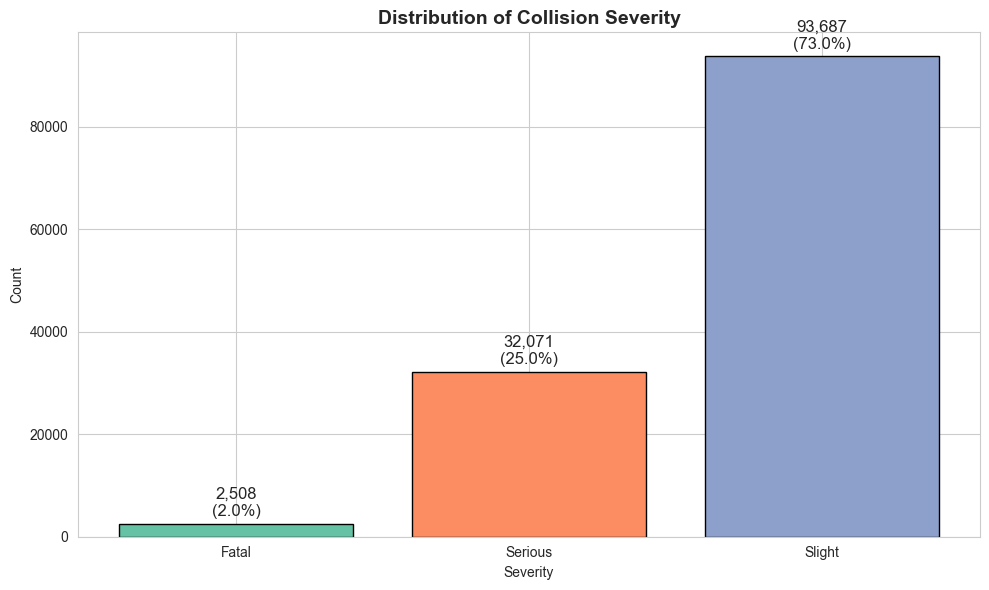

In [ ]:
# Chart 1: Target variable distribution
fig, ax = plt.subplots(figsize=(10, 6))
counts = final_df['collision_severity'].value_counts().sort_index()
percents = final_df['collision_severity'].value_counts(normalize=True).sort_index() * 100
labels = [severity_map[i] for i in counts.index]
bars = ax.bar(labels, counts.values, color=sns.color_palette('Set2', 3), edgecolor='black')
for bar, pct, cnt in zip(bars, percents.values, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12)
ax.set_title('Distribution of Collision Severity', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Severity')
plt.tight_layout()
plt.show()


**Key Finding:** The dataset is highly imbalanced — Slight injuries dominate (73%), while Fatal cases are extremely rare (2%). This class imbalance must be addressed during modeling.

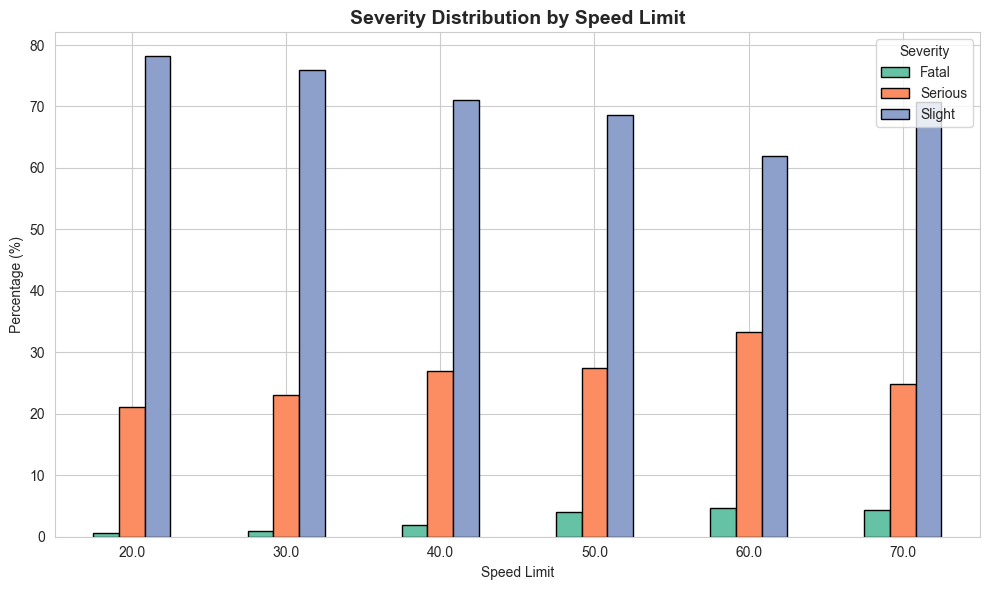

In [ ]:
# Chart 2: Severity x Speed Limit — grouped percentage bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ct = pd.crosstab(final_df['speed_limit'], final_df['collision_severity'], normalize='index') * 100
ct.columns = [severity_map[c] for c in ct.columns]
ct = ct[['Fatal', 'Serious', 'Slight']]
ct.plot(kind='bar', stacked=False, ax=ax, edgecolor='black')
ax.set_title('Severity Distribution by Speed Limit', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Speed Limit')
ax.legend(title='Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Key Finding:** Collision severity generally increases with speed limit — Fatal and Serious proportions rise steadily from 20 to 60 mph, where they peak. At 70 mph, the Serious rate drops slightly, likely because 70 mph roads (mainly motorways) tend to have better infrastructure such as barriers, lane separation, and controlled access. Nonetheless, high-speed roads (60+ mph) remain far more dangerous than lower-speed zones overall, confirming speed limit as a key predictor of severity.

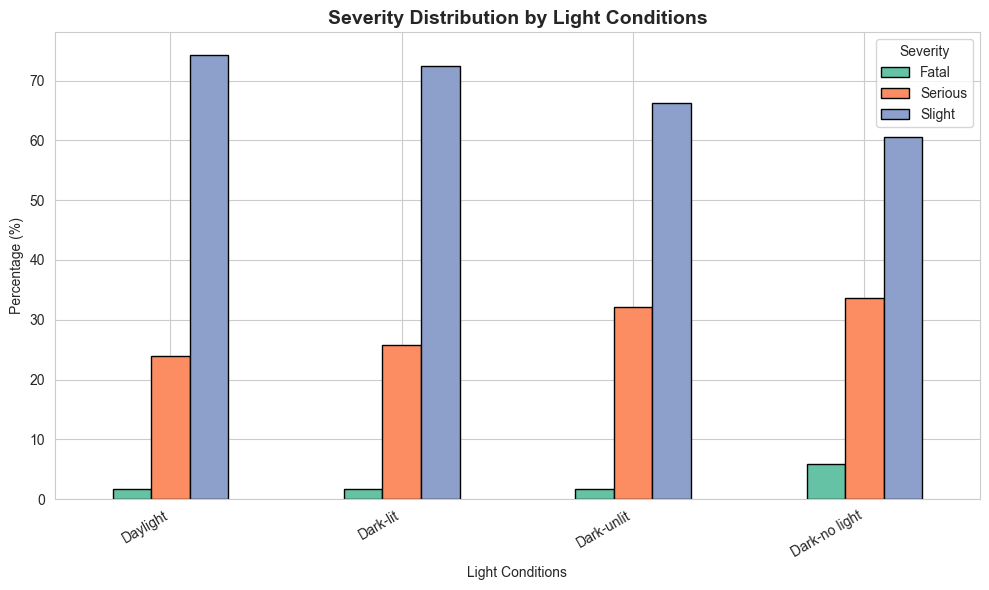

In [ ]:
# Chart 3: Severity x Light Conditions — grouped percentage bar chart
light_labels = {1: 'Daylight', 4: 'Dark-lit', 5: 'Dark-unlit', 6: 'Dark-no light', 7: 'Darkness-lighting unknown'}
fig, ax = plt.subplots(figsize=(10, 6))
ct = pd.crosstab(final_df['light_conditions'], final_df['collision_severity'], normalize='index') * 100
ct.columns = [severity_map[c] for c in ct.columns]
ct = ct[['Fatal', 'Serious', 'Slight']]
ct = ct.reindex([1, 4, 5, 6])
ct.index = [light_labels.get(i) for i in ct.index]
ct.plot(kind='bar', stacked=False, ax=ax, edgecolor='black')
ax.set_title('Severity Distribution by Light Conditions', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Light Conditions')
ax.legend(title='Severity')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Key Finding:** Darkness (especially no light roads) is associated with higher Fatal and Serious percentages compared to daylight conditions, highlighting road lighting as an important safety factor.

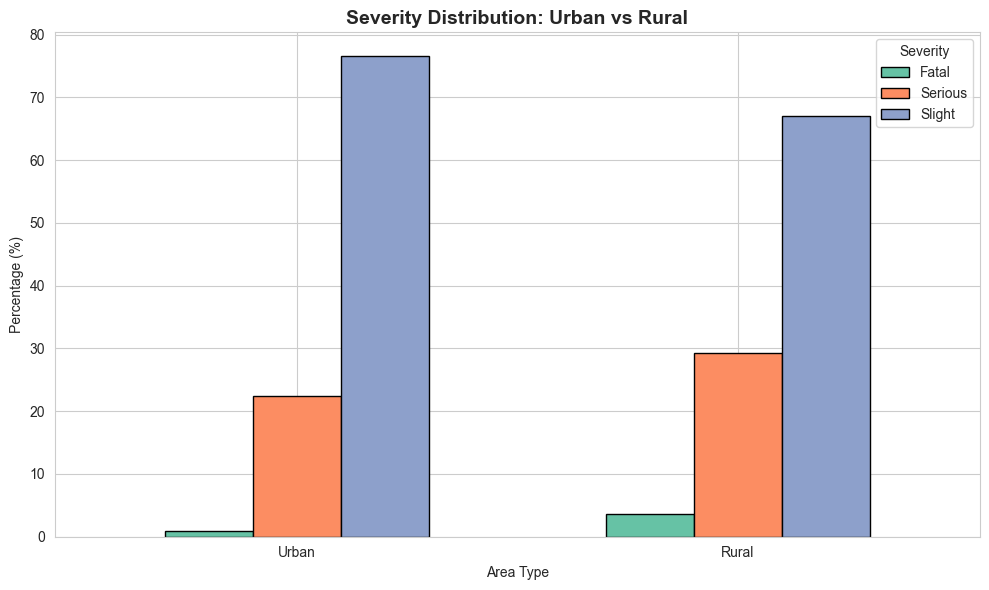

In [ ]:
# Chart 4: Severity x Urban/Rural
urban_labels = {1: 'Urban', 2: 'Rural'}
fig, ax = plt.subplots(figsize=(10, 6))
ct = pd.crosstab(final_df['urban_or_rural_area'], final_df['collision_severity'], normalize='index') * 100
ct.columns = [severity_map[c] for c in ct.columns]
ct = ct[['Fatal', 'Serious', 'Slight']]
ct.index = [urban_labels.get(i) for i in ct.index]
ct.plot(kind='bar', stacked=False, ax=ax, edgecolor='black', width=0.6)
ax.set_title('Severity Distribution: Urban vs Rural', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Area Type')
ax.legend(title='Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Key Finding:** Rural areas have a substantially higher proportion of Fatal and Serious collisions compared to urban areas, likely due to higher speeds and longer emergency response times.

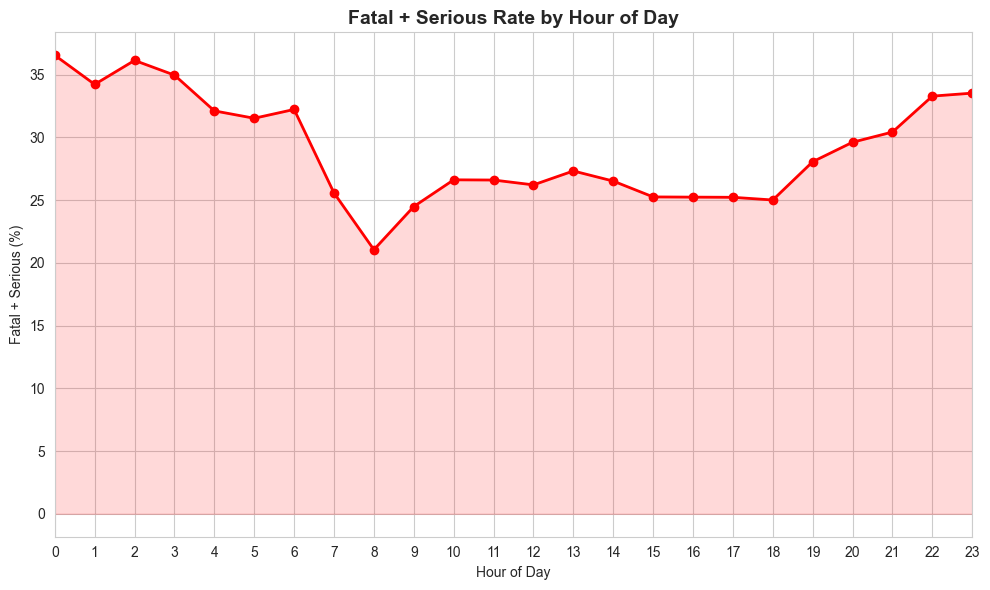

In [ ]:
# Chart 5: Severity x Hour of Day — Fatal+Serious ratio line chart
plot_df = df[['collision_severity', 'hour']].copy()
plot_df['is_fatal_serious'] = plot_df['collision_severity'].isin([1, 2]).astype(int)
total = plot_df.groupby('hour')['collision_severity'].count()
fatal_serious = plot_df.groupby('hour')['is_fatal_serious'].sum()
hourly = pd.DataFrame({'total': total, 'fatal_serious': fatal_serious})
hourly['ratio'] = hourly['fatal_serious'] / hourly['total'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(hourly.index, hourly['ratio'], marker='o', linewidth=2, color='red')
ax.fill_between(hourly.index, hourly['ratio'], alpha=0.15, color='red')
ax.set_title('Fatal + Serious Rate by Hour of Day', fontsize=14, fontweight='bold')
ax.set_ylabel('Fatal + Serious (%)')
ax.set_xlabel('Hour of Day')
ax.set_xticks(range(0, 24))
ax.set_xlim(0, 23)
plt.tight_layout()
plt.show()


**Key Finding:** The Fatal+Serious rate peaks during late night / early morning hours (midnight to 5 AM), likely due to fatigue, impaired driving, and reduced visibility. Daytime hours show the lowest severe-collision rates.

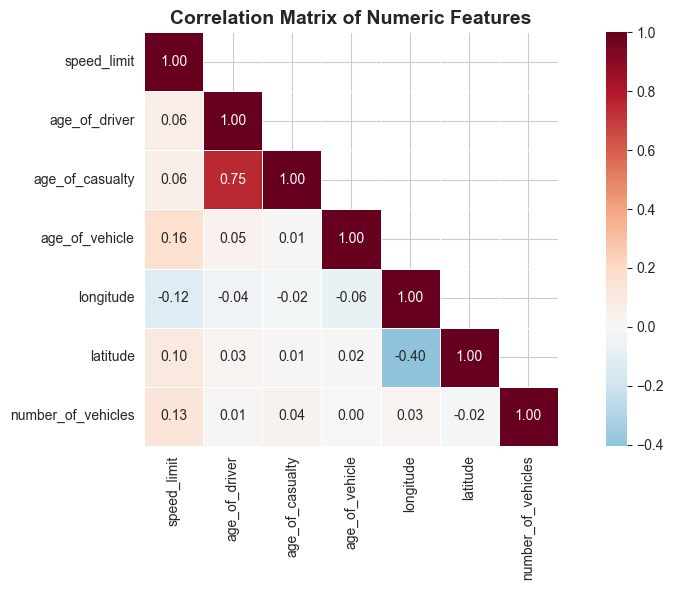

In [ ]:
# Chart 6: Numeric feature correlation heatmap
heatmap_cols = ['speed_limit', 'age_of_driver', 'age_of_casualty', 'age_of_vehicle',
                'longitude', 'latitude', 'number_of_vehicles']
corr = final_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Finding:** Most numeric features show low inter-correlation, suggesting they contribute independent information. The strongest correlation is between age_of_driver and age_of_casualty, which is expected since drivers are often casualties themselves.

# Step 2: Data Preprocessing

## 2.1 Check missing values

In [ ]:
# 2.1 Check missing values
missing = final_df.isnull().sum().sort_values(ascending=False)
missing_any = missing[missing > 0]
if len(missing_any) == 0:
    print("No missing values in final_df.")
else:
    print("Missing values found:")
    for col in missing_any.index:
        print(f"  {col:40s} dtype={str(final_df[col].dtype):10s} missing={missing_any[col]} ({missing_any[col]/len(final_df)*100:.1f}%)")


Missing values found:
  special_conditions_at_site               dtype=object     missing=77849 (60.7%)
  junction_control                         dtype=object     missing=55818 (43.5%)
  casualty_distance_banding                dtype=object     missing=17273 (13.5%)
  driver_distance_banding                  dtype=object     missing=15882 (12.4%)
  second_road_class                        dtype=object     missing=15644 (12.2%)
  junction_detail                          dtype=object     missing=8320 (6.5%)
  age_of_driver                            dtype=float64    missing=7188 (5.6%)
  vehicle_manoeuvre                        dtype=object     missing=3738 (2.9%)
  age_of_casualty                          dtype=float64    missing=2552 (2.0%)
  vehicle_location_restricted_lane         dtype=object     missing=2177 (1.7%)
  first_point_of_impact                    dtype=object     missing=1795 (1.4%)
  vehicle_leaving_carriageway              dtype=object     missing=1772 (1.4%)
  skiddi

# 2.2 Missing value imputation

In [ ]:
# 2.2 Missing value imputation

print(f"Missing before imputation: {final_df.isnull().sum().sum()}")

# Metadata-driven fills special_conditions_at_site: 0 = "None"
final_df['special_conditions_at_site'] = final_df['special_conditions_at_site'].fillna('0')

# Metadata-driven fills second_road_class: 6 = "Unclassified"
final_df['second_road_class'] = final_df['second_road_class'].fillna('6.0')

# Group-wise median: age distribution may differ by severity
final_df['age_of_driver'] = final_df.groupby('collision_severity')['age_of_driver'] \
    .transform(lambda x: x.fillna(x.median()))
final_df['age_of_casualty'] = final_df.groupby('collision_severity')['age_of_casualty'] \
    .transform(lambda x: x.fillna(x.median()))

# Remaining categoricals -> 'Unknown'; floats -> median
for col in final_df.columns:
    if final_df[col].isnull().sum() == 0:
        continue
    if final_df[col].dtype == 'object':
        final_df[col] = final_df[col].fillna('Unknown')
    else:
        final_df[col] = final_df[col].fillna(final_df[col].median())

print(f"Missing after imputation: {final_df.isnull().sum().sum()}")
print(f"Shape: {final_df.shape}")


final_df_for_ARM=final_df.copy()


Missing before imputation: 222704
Missing after imputation: 0
Shape: (128266, 42)


In [ ]:
final_df.dtypes.value_counts()

object     29
float64     7
int64       5
int32       1
Name: count, dtype: int64

In [ ]:
cat_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Total categorical features: {len(cat_cols)}\n")
total = 0
for col in cat_cols:
    num = final_df[col].nunique()
    total += num
    print(f"  {col}: {num} unique values")

print(f"  {col}: {num} unique values")
print(f"Total unique values: {total}")

Total categorical features: 29

  casualty_type: 21 unique values
  vehicle_type: 20 unique values
  vehicle_manoeuvre: 17 unique values
  carriageway_hazards: 13 unique values
  hit_object_off_carriageway: 12 unique values
  hit_object_in_carriageway: 12 unique values
  junction_location: 10 unique values
  pedestrian_movement: 10 unique values
  vehicle_leaving_carriageway: 10 unique values
  pedestrian_crossing: 9 unique values
  weather_conditions: 9 unique values
  special_conditions_at_site: 10 unique values
  vehicle_location_restricted_lane: 7 unique values
  second_road_class: 8 unique values
  junction_detail: 7 unique values
  skidding_and_overturning: 7 unique values
  journey_purpose_of_driver: 7 unique values
  first_road_class: 6 unique values
  first_point_of_impact: 6 unique values
  road_surface_conditions: 6 unique values
  road_type: 6 unique values
  driver_distance_banding: 6 unique values
  junction_control: 5 unique values
  casualty_distance_banding: 6 unique v

# 2.3 Encode categorical variables (LabelEncoder/One-Hot)

In [ ]:
# 2.3 Encode categorical variables (LabelEncoder/One-Hot)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
df_clean = final_df.copy()

# LabelEncoder
df_label = df_clean.copy()
label_encoders = {}
cat_cols = df_label.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col].astype(str))
    label_encoders[col] = le

# One-Hot
df_onehot = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Considered one-hot but some categorical features have too many unique values which would explode the feature space.
# LabelEncoder is acceptable here since we're using tree-based models.
final_df = df_label
print(f"Encoded {len(cat_cols)} columns: {cat_cols}")

Encoded 29 columns: ['casualty_type', 'vehicle_type', 'vehicle_manoeuvre', 'carriageway_hazards', 'hit_object_off_carriageway', 'hit_object_in_carriageway', 'junction_location', 'pedestrian_movement', 'vehicle_leaving_carriageway', 'pedestrian_crossing', 'weather_conditions', 'special_conditions_at_site', 'vehicle_location_restricted_lane', 'second_road_class', 'junction_detail', 'skidding_and_overturning', 'journey_purpose_of_driver', 'first_road_class', 'first_point_of_impact', 'road_surface_conditions', 'road_type', 'driver_distance_banding', 'junction_control', 'casualty_distance_banding', 'light_conditions', 'casualty_class', 'sex_of_driver', 'sex_of_casualty', 'urban_or_rural_area']


# 2.4 Train/Test split (80:20, stratified -> because of data imbalance)

In [ ]:
# 2.4 Train/Test split (80:20, stratified -> because of data imbalance)
X = final_df.drop(columns=['collision_severity'])
y = final_df['collision_severity']

# Map target 1,2,3 -> 0,1,2 for XGBoost compatibility
y = y.map({1: 0, 2: 1, 3: 2})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

print(f"\nTrain class distribution:")
train_counts = y_train.value_counts().sort_index().rename({0:'Fatal', 1:'Serious', 2:'Slight'})
train_pct = (train_counts / len(y_train) * 100).round(2)
print(pd.DataFrame({'count': train_counts, 'pct(%)': train_pct}))

print(f"\nTest class distribution:")
test_counts = y_test.value_counts().sort_index().rename({0:'Fatal', 1:'Serious', 2:'Slight'})
test_pct = (test_counts / len(y_test) * 100).round(2)
print(pd.DataFrame({'count': test_counts, 'pct(%)': test_pct}))

X_train: (102612, 41), X_test: (25654, 41)

Train class distribution:
                    count  pct(%)
collision_severity               
Fatal                2006    1.95
Serious             25657   25.00
Slight              74949   73.04

Test class distribution:
                    count  pct(%)
collision_severity               
Fatal                 502    1.96
Serious              6414   25.00
Slight              18738   73.04


# 2.5 Standardize numeric features

In [ ]:
# 2.5 Standardize numeric features
num_features = ['longitude', 'latitude', 'number_of_vehicles', 'speed_limit',
                'age_of_vehicle', 'age_of_driver', 'age_of_casualty']
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])  # fit on train
X_test[num_features] = scaler.transform(X_test[num_features])        # only transform
scaler = StandardScaler()
final_df[num_features] = scaler.fit_transform(final_df[num_features])
print("Standardized numeric features:", num_features)

Standardized numeric features: ['longitude', 'latitude', 'number_of_vehicles', 'speed_limit', 'age_of_vehicle', 'age_of_driver', 'age_of_casualty']


# Step 3: Modeling

## Model 1: Logistic Regression (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

lr.fit(X_train, y_train)

print("\n=== Train Classification Report ===")
print(classification_report(y_train, lr.predict(X_train), target_names=['Fatal','Serious','Slight']))
print("\n=== Test Classification Report ===")
y_pred_lr = lr.predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=['Fatal','Serious','Slight']))


CV Accuracy: 0.5123 +/- 0.0053

=== Train Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.06      0.68      0.11      2006
     Serious       0.32      0.34      0.33     25657
      Slight       0.82      0.57      0.67     74949

    accuracy                           0.51    102612
   macro avg       0.40      0.53      0.37    102612
weighted avg       0.68      0.51      0.58    102612


=== Test Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.06      0.69      0.11       502
     Serious       0.32      0.35      0.34      6414
      Slight       0.83      0.56      0.67     18738

    accuracy                           0.51     25654
   macro avg       0.40      0.53      0.37     25654
weighted avg       0.69      0.51      0.58     25654



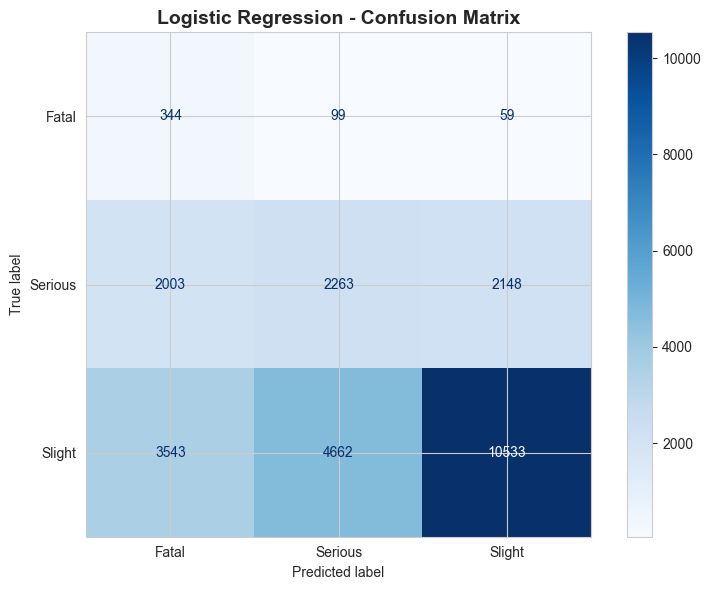

In [ ]:
# LR Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['Fatal','Serious','Slight'], cmap='Blues', ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [20, 50, 80, None],
    'min_samples_split': [10,20,50],
}

# param_dist_rf = {
# 'n_estimators': [100, 200, 300],
# 'max_depth': [10, 15, 20, None],
# 'min_samples_split': [2, 5, 10],
# }

rs_rf = RandomizedSearchCV(rf, param_dist_rf, n_iter=20, cv=3,
                           scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)
rs_rf.fit(X_train, y_train)

print(f"\nBest params: {rs_rf.best_params_}")
print(f"Best CV f1_macro: {rs_rf.best_score_:.4f}")

print("\n=== Train Classification Report ===")
print(classification_report(y_train, rs_rf.predict(X_train), target_names=['Fatal','Serious','Slight']))
print("\n=== Test Classification Report ===")
y_pred_rf = rs_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Fatal','Serious','Slight']))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'n_estimators': 200, 'min_samples_split': 20, 'max_depth': 50}
Best CV f1_macro: 0.6047

=== Train Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.94      1.00      0.97      2006
     Serious       0.90      0.95      0.92     25657
      Slight       0.98      0.96      0.97     74949

    accuracy                           0.96    102612
   macro avg       0.94      0.97      0.96    102612
weighted avg       0.96      0.96      0.96    102612


=== Test Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.77      0.38      0.51       502
     Serious       0.56      0.54      0.55      6414
      Slight       0.84      0.87      0.85     18738

    accuracy                           0.77     25654
   macro avg       0.73      0.59      0.64     25654
weighted avg       0.77      0.77      0.77     25654



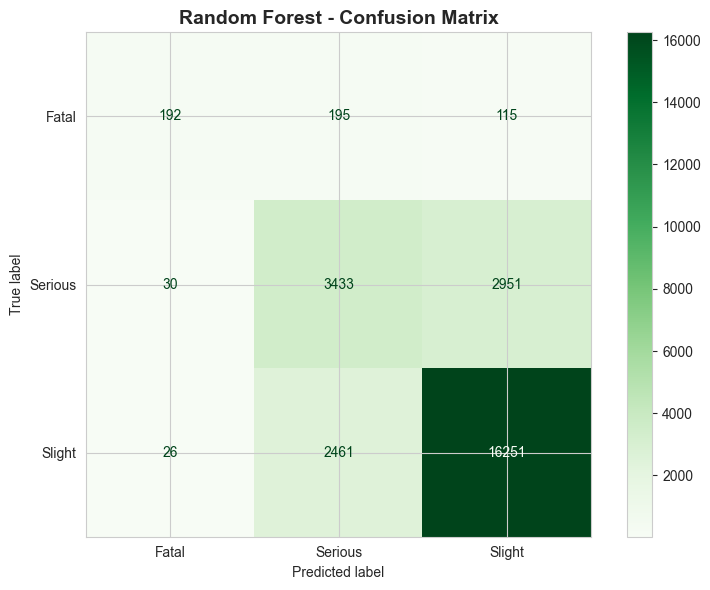

In [ ]:
# RF Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Fatal','Serious','Slight'], cmap='Greens', ax=ax)
ax.set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Model 3: XGBoost

In [ ]:
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight

xgb = XGBClassifier(objective='multi:softmax', num_class=3,
                     eval_metric='mlogloss', random_state=42, use_label_encoder=False)

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

rs_xgb = RandomizedSearchCV(xgb, param_dist_xgb, n_iter=20, cv=3,
                            scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

sample_weights = compute_sample_weight('balanced', y_train)
rs_xgb.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nBest params: {rs_xgb.best_params_}")
print(f"Best CV f1_macro: {rs_xgb.best_score_:.4f}")

print("\n=== Train Classification Report ===")
print(classification_report(y_train, rs_xgb.predict(X_train), target_names=['Fatal','Serious','Slight']))
print("\n=== Test Classification Report ===")
y_pred_xgb = rs_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=['Fatal','Serious','Slight']))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV f1_macro: 0.6205

=== Train Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.20      0.95      0.33      2006
     Serious       0.48      0.65      0.55     25657
      Slight       0.90      0.70      0.79     74949

    accuracy                           0.69    102612
   macro avg       0.53      0.77      0.56    102612
weighted avg       0.78      0.69      0.72    102612


=== Test Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.14      0.68      0.24       502
     Serious       0.43      0.58      0.49      6414
      Slight       0.87      0.67      0.76     18738

    accuracy                           0.65     25654
   macro avg       0.48      0.64      0.50     25654
weighted avg     

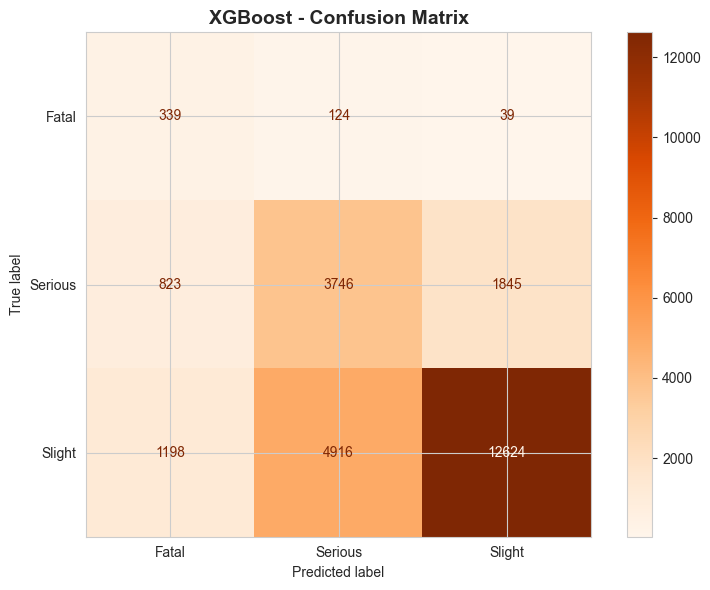

In [ ]:
# XGBoost Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
    display_labels=['Fatal','Serious','Slight'], cmap='Oranges', ax=ax)
ax.set_title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

models = {'Logistic Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb}
results = []

for name, y_pred in models.items():
    results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Macro-F1': f1_score(y_test, y_pred, average='macro'),
        'Weighted-F1': f1_score(y_test, y_pred, average='weighted'),
        'Fatal Recall': recall_score(y_test, y_pred, labels=[0], average=None)[0],
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4).to_string())


                     Test Accuracy  Macro-F1  Weighted-F1  Fatal Recall
Model                                                                  
Logistic Regression         0.5122    0.3712       0.5751        0.6853
Random Forest               0.7748    0.6384       0.7711        0.3825
XGBoost                     0.6513    0.4964       0.6826        0.6753


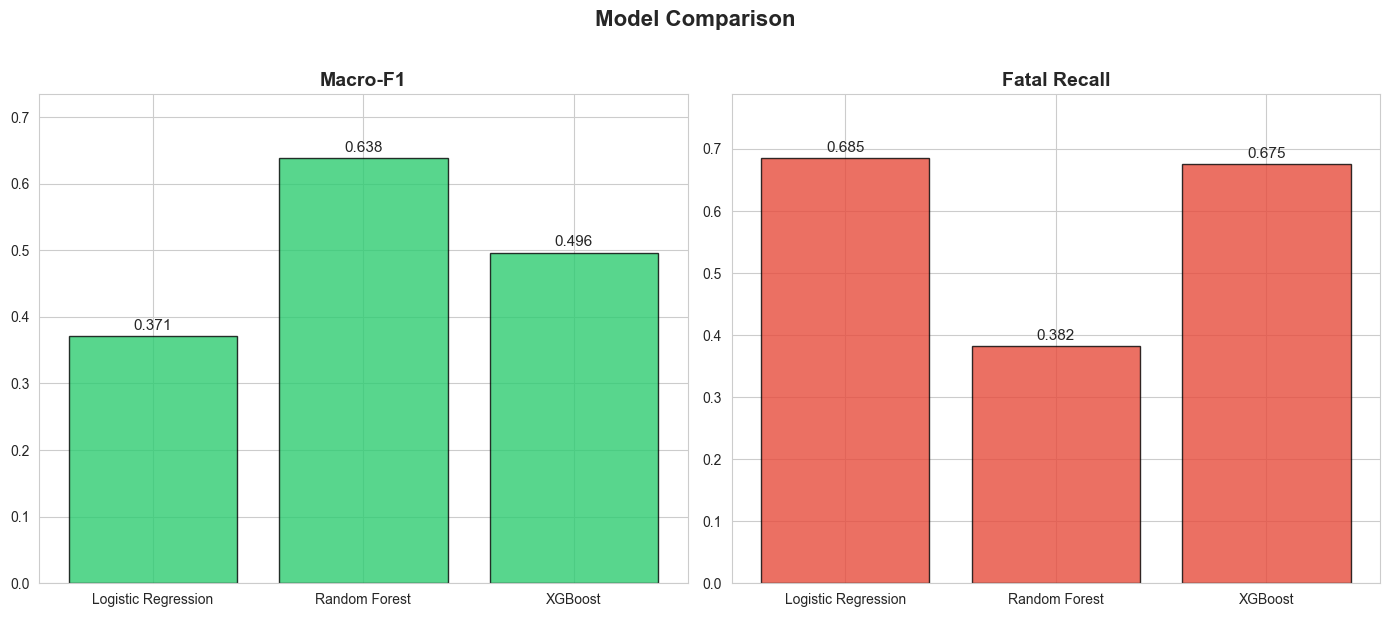

In [ ]:
# Comparison bar chart: Macro-F1 and Fatal Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
metrics = ['Macro-F1', 'Fatal Recall']
colors = ['#2ecc71', '#e74c3c']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df.index, results_df[metric], color=color, edgecolor='black', alpha=0.8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(results_df[metric]) * 1.15)

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Step 4: Model Diagnosis & Improvement

## Diagnostic Summary

The baseline model evaluation in Step 5 revealed two key issues that need to be addressed before finalising the model selection.

**Overfitting in Random Forest**: The original Random Forest achieved a Train Macro-F1 of 0.96 but only 0.64 on the test set, resulting in a gap of 0.32 — a clear sign of overfitting. This is largely attributable to the unconstrained tree depth (max_depth=50) and the high-dimensional feature space (41 features), which allowed the model to memorise training patterns rather than learn generalisable ones.

**Poor performance on minority classes**: Across all three models, the Fatal class (comprising only ~2% of samples) proved difficult to predict reliably. Despite applying class_weight='balanced', Fatal Precision remained extremely low (e.g. 0.06 for Logistic Regression, 0.14 for XGBoost), indicating that balanced class weights alone are insufficient for such extreme imbalance.

To address these issues, we adopt the following improvement strategies:

1. **Feature selection**: Selecting the top-20 most important features based on XGBoost's feature importance scores (chosen because XGBoost exhibited the smallest train-test gap, making its importance estimates more trustworthy) to reduce noise and mitigate overfitting in Random Forest.
2. **SMOTE oversampling**: Applying Synthetic Minority Over-sampling Technique (SMOTE) to the training set to generate synthetic samples for underrepresented classes, particularly Fatal, giving the model more balanced learning signals.
3. **Conservative hyperparameter tuning**: Restricting Random Forest's tree depth and increasing minimum leaf size to prevent the model from overfitting to training data.

Note that dimensionality reduction techniques such as PCA were deliberately not adopted. Since the primary objective of this project is to identify interpretable risk factors and provide actionable policy recommendations for road safety authorities, preserving the original physical meaning of each feature (e.g. speed_limit, light_conditions, urban_or_rural_area) is essential. PCA would transform features into abstract linear combinations, making it impossible to translate findings into specific, actionable insights.

## Step 4.1: Feature Selection — Reduced Feature Set

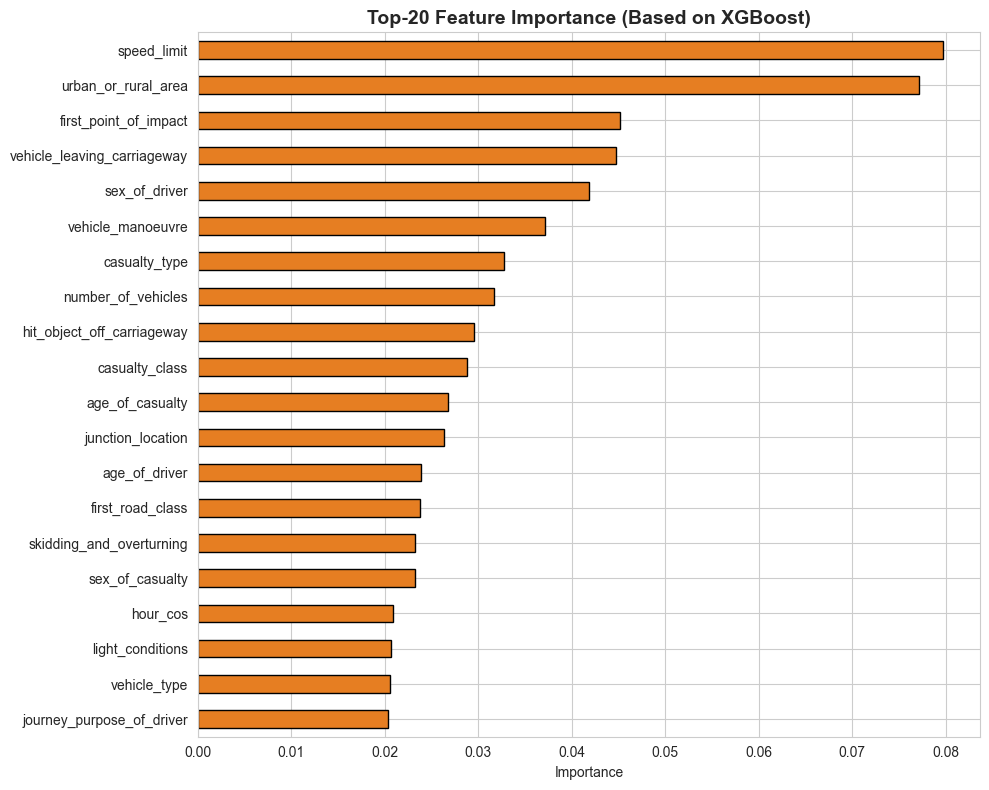


Selected 20 features:
   1. speed_limit
   2. urban_or_rural_area
   3. first_point_of_impact
   4. vehicle_leaving_carriageway
   5. sex_of_driver
   6. vehicle_manoeuvre
   7. casualty_type
   8. number_of_vehicles
   9. hit_object_off_carriageway
  10. casualty_class
  11. age_of_casualty
  12. junction_location
  13. age_of_driver
  14. first_road_class
  15. skidding_and_overturning
  16. sex_of_casualty
  17. hour_cos
  18. light_conditions
  19. vehicle_type
  20. journey_purpose_of_driver


In [ ]:
# Use XGBoost importance (less overfitted than RF) for feature selection
xgb_importances = pd.Series(
    rs_xgb.best_estimator_.feature_importances_, index=X_train.columns
)

top_k = 20
top_features = xgb_importances.sort_values(ascending=False).head(top_k).index.tolist()

# Plot top-20 feature importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb_importances.sort_values(ascending=False).head(top_k).sort_values().plot(
    kind='barh', ax=ax, color='#e67e22', edgecolor='black')
ax.set_title('Top-20 Feature Importance (Based on XGBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nSelected {top_k} features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2d}. {f}")


In [ ]:
# Build reduced datasets for all improved models
X_train_fs = X_train[top_features]
X_test_fs = X_test[top_features]
print(f"Reduced X_train: {X_train_fs.shape}, X_test: {X_test_fs.shape}")


Reduced X_train: (102612, 20), X_test: (25654, 20)


## Step 4.2: RF v2 — Feature Selection + Adjust Parameters

In [ ]:
# RF v2: fix overfitting with limited depth + fewer features
rf_v2 = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist_rf_v2 = {
    'n_estimators': [200, 300, 400],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
}

# param_dist_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [20, 50, 80, None],
#     'min_samples_split': [10,20,50],
# }

rs_rf_v2 = RandomizedSearchCV(
    rf_v2, param_dist_rf_v2, n_iter=20, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1
)
rs_rf_v2.fit(X_train_fs, y_train)

print(f"\nBest params: {rs_rf_v2.best_params_}")
print(f"Best CV f1_macro: {rs_rf_v2.best_score_:.4f}")

print("\n=== Train Classification Report ===")
print(classification_report(y_train, rs_rf_v2.predict(X_train_fs), target_names=['Fatal','Serious','Slight']))
print("=== Test Classification Report ===")
y_pred_rf_v2 = rs_rf_v2.predict(X_test_fs)
print(classification_report(y_test, y_pred_rf_v2, target_names=['Fatal','Serious','Slight']))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_depth': 20}
Best CV f1_macro: 0.5021

=== Train Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.38      0.99      0.55      2006
     Serious       0.54      0.75      0.63     25657
      Slight       0.92      0.75      0.83     74949

    accuracy                           0.76    102612
   macro avg       0.61      0.83      0.67    102612
weighted avg       0.81      0.76      0.77    102612

=== Test Classification Report ===
              precision    recall  f1-score   support

       Fatal       0.22      0.51      0.31       502
     Serious       0.42      0.59      0.49      6414
      Slight       0.85      0.70      0.77     18738

    accuracy                           0.67     25654
   macro avg       0.50      0.60      0.52     25654
weighted avg       0.73      0.67

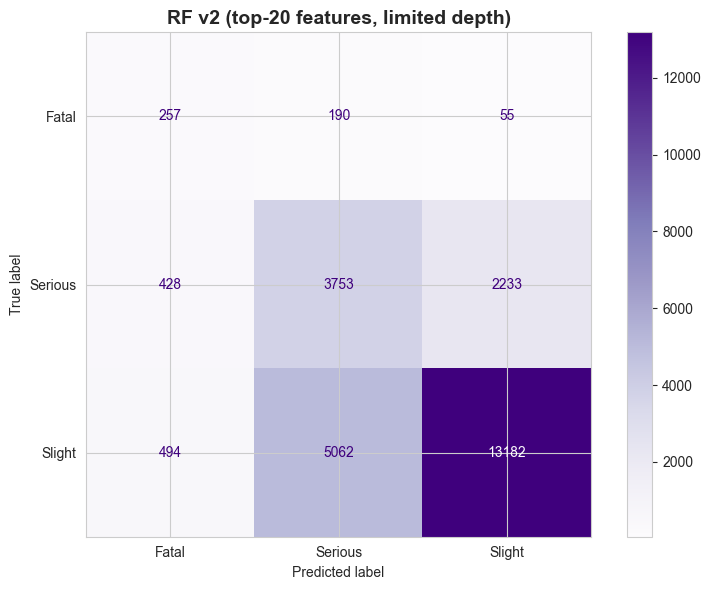

In [ ]:
# RF v2 Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_v2,
    display_labels=['Fatal','Serious','Slight'], cmap='Purples', ax=ax)
ax.set_title('RF v2 (top-20 features, limited depth)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 4.3: RF v2 + SMOTE

In [ ]:
!pip install --upgrade imbalanced-learn scikit-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_fs_smote, y_train_fs_smote = smote.fit_resample(X_train_fs, y_train)

print(f"Before SMOTE: {dict(y_train.value_counts().sort_index())}")
print(f"After SMOTE:  {dict(pd.Series(y_train_fs_smote).value_counts().sort_index())}")


Before SMOTE: {0: np.int64(2006), 1: np.int64(25657), 2: np.int64(74949)}
After SMOTE:  {0: np.int64(74949), 1: np.int64(74949), 2: np.int64(74949)}


In [ ]:
# RF v2 + SMOTE
rf_v2_smote = RandomForestClassifier(random_state=42)

rs_rf_v2_smote = RandomizedSearchCV(
    rf_v2_smote, param_dist_rf_v2, n_iter=20, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1
)
rs_rf_v2_smote.fit(X_train_fs_smote, y_train_fs_smote)

print(f"\nBest params: {rs_rf_v2_smote.best_params_}")
print(f"Best CV f1_macro: {rs_rf_v2_smote.best_score_:.4f}")

print("\n=== Train Classification Report (on SMOTE data) ===")
print(classification_report(y_train_fs_smote, rs_rf_v2_smote.predict(X_train_fs_smote),
                            target_names=['Fatal','Serious','Slight']))
print("=== Test Classification Report (original test set) ===")
y_pred_rf_v2_smote = rs_rf_v2_smote.predict(X_test_fs)
print(classification_report(y_test, y_pred_rf_v2_smote, target_names=['Fatal','Serious','Slight']))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_depth': 20}
Best CV f1_macro: 0.7654

=== Train Classification Report (on SMOTE data) ===
              precision    recall  f1-score   support

       Fatal       0.90      0.98      0.94     74949
     Serious       0.84      0.76      0.80     74949
      Slight       0.84      0.85      0.84     74949

    accuracy                           0.86    224847
   macro avg       0.86      0.86      0.86    224847
weighted avg       0.86      0.86      0.86    224847

=== Test Classification Report (original test set) ===
              precision    recall  f1-score   support

       Fatal       0.19      0.43      0.26       502
     Serious       0.45      0.45      0.45      6414
      Slight       0.82      0.79      0.81     18738

    accuracy                           0.70     25654
   macro avg       0.49      0.56      0.51     256

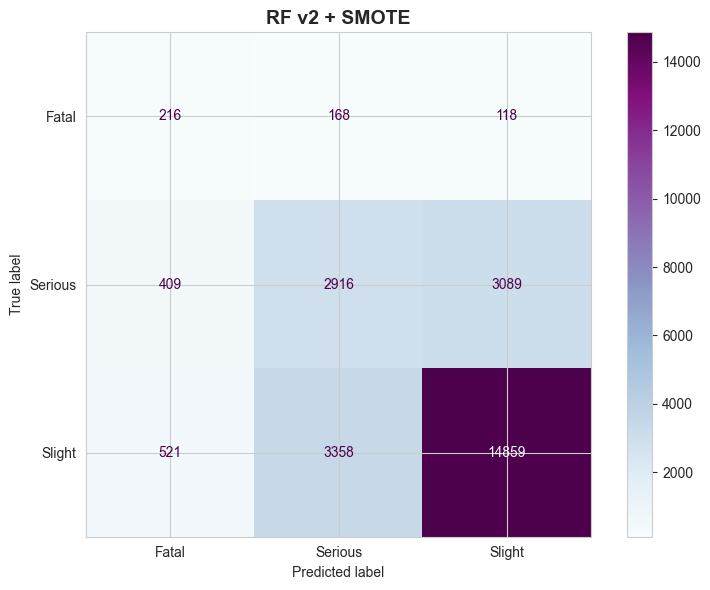

In [ ]:
# RF v2 + SMOTE Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_v2_smote,
    display_labels=['Fatal','Serious','Slight'], cmap='BuPu', ax=ax)
ax.set_title('RF v2 + SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Finding:** Comparing the three RF variants on the test set, the original RF (with all features and `class_weight='balanced'`) achieves the best test Macro F1 (0.64), outperforming both the Top-K feature selection version (0.52) and the Top-K + SMOTE version (0.51). Although applying Top-K feature selection reduces the train-test gap, it does so at the cost of lower generalisation performance, indicating that the removed features contain useful predictive information. Combining Top-K with SMOTE further fails to improve results — while SMOTE inflates training metrics, the test Macro F1 drops even further, suggesting the synthetic samples do not reflect the true minority-class distribution. Since all three versions exhibit overfitting to varying degrees, the model with the strongest test set performance — the original RF — is retained as the final Random Forest model.

## Step 4.4: XGBoost v2 — SMOTE + Feature Selection

In [ ]:
# XGBoost v2: SMOTE + reduced features
xgb_v2 = XGBClassifier(
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=42, use_label_encoder=False
)

param_dist_xgb_v2 = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 10],
}

rs_xgb_v2 = RandomizedSearchCV(
    xgb_v2, param_dist_xgb_v2, n_iter=20, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1
)
rs_xgb_v2.fit(X_train_fs_smote, y_train_fs_smote)

print(f"\nBest params: {rs_xgb_v2.best_params_}")
print(f"Best CV f1_macro: {rs_xgb_v2.best_score_:.4f}")

print("\n=== Train Classification Report (on SMOTE data) ===")
print(classification_report(y_train_fs_smote, rs_xgb_v2.predict(X_train_fs_smote),
                            target_names=['Fatal','Serious','Slight']))
print("=== Test Classification Report (original test set) ===")
y_pred_xgb_v2 = rs_xgb_v2.predict(X_test_fs)
print(classification_report(y_test, y_pred_xgb_v2, target_names=['Fatal','Serious','Slight']))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV f1_macro: 0.7900

=== Train Classification Report (on SMOTE data) ===
              precision    recall  f1-score   support

       Fatal       0.95      0.98      0.96     74949
     Serious       0.94      0.76      0.84     74949
      Slight       0.83      0.97      0.89     74949

    accuracy                           0.90    224847
   macro avg       0.91      0.90      0.90    224847
weighted avg       0.91      0.90      0.90    224847

=== Test Classification Report (original test set) ===
              precision    recall  f1-score   support

       Fatal       0.35      0.30      0.32       502
     Serious       0.60      0.31      0.41      6414
      Slight       0.79      0.93      0.86     18738

    accuracy                           0.76     25654
   macro avg 

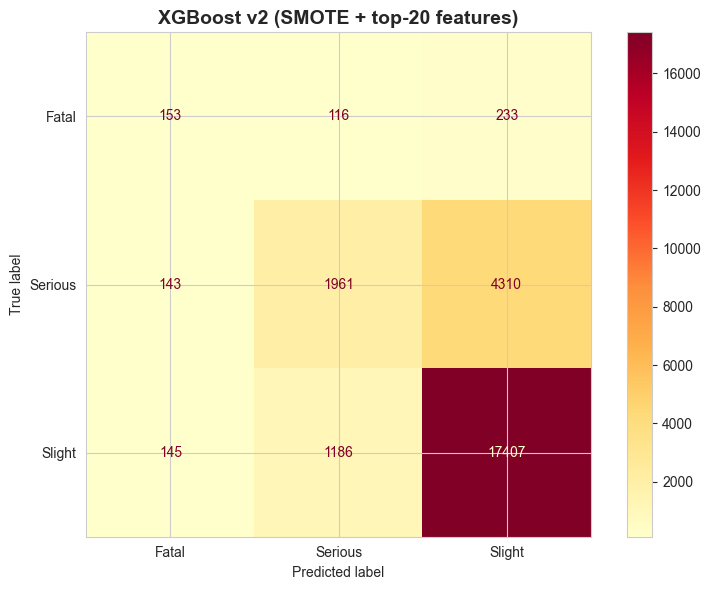

In [ ]:
# XGBoost v2 Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_v2,
    display_labels=['Fatal','Serious','Slight'], cmap='YlOrRd', ax=ax)
ax.set_title('XGBoost v2 (SMOTE + top-20 features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 4.5: XGBoost v3 — SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {dict(y_train.value_counts().sort_index())}")
print(f"After SMOTE:  {dict(pd.Series(y_train_smote).value_counts().sort_index())}")

Before SMOTE: {0: np.int64(2006), 1: np.int64(25657), 2: np.int64(74949)}
After SMOTE:  {0: np.int64(74949), 1: np.int64(74949), 2: np.int64(74949)}


In [ ]:
# XGBoost v3: SMOTE
xgb_v3 = XGBClassifier(
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=42, use_label_encoder=False
)


rs_xgb_v3 = RandomizedSearchCV(
    xgb_v3, param_dist_xgb_v2, n_iter=20, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1
)
rs_xgb_v3.fit(X_train_smote, y_train_smote)


print(f"\nBest params: {rs_xgb_v3.best_params_}")
print(f"Best CV f1_macro: {rs_xgb_v3.best_score_:.4f}")

print("\n=== Train Classification Report (on SMOTE data) ===")
print(classification_report(y_train_smote, rs_xgb_v3.predict(X_train_smote),
                            target_names=['Fatal','Serious','Slight']))
print("=== Test Classification Report (original test set) ===")
y_pred_xgb_v3 = rs_xgb_v3.predict(X_test)
print(classification_report(y_test, y_pred_xgb_v3, target_names=['Fatal','Serious','Slight']))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV f1_macro: 0.8226

=== Train Classification Report (on SMOTE data) ===
              precision    recall  f1-score   support

       Fatal       0.98      0.99      0.99     74949
     Serious       0.98      0.86      0.92     74949
      Slight       0.88      0.99      0.93     74949

    accuracy                           0.95    224847
   macro avg       0.95      0.95      0.94    224847
weighted avg       0.95      0.95      0.94    224847

=== Test Classification Report (original test set) ===
              precision    recall  f1-score   support

       Fatal       0.62      0.34      0.44       502
     Serious       0.67      0.36      0.47      6414
      Slight       0.81      0.94      0.87     18738

    accuracy                           0.78     25654
   macro avg 

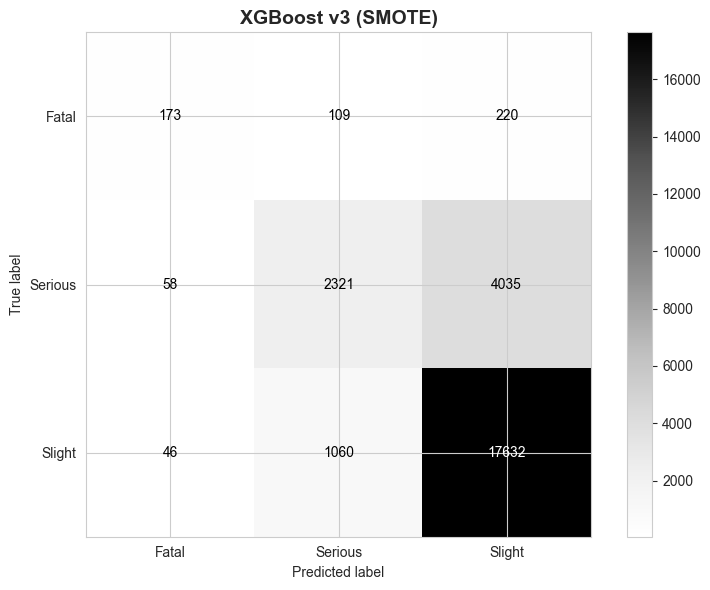

In [ ]:
# XGBoost v3 Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_v3,
    display_labels=['Fatal','Serious','Slight'], cmap='Greys', ax=ax)
ax.set_title('XGBoost v3 (SMOTE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Finding:** Among the three XGBoost variants, XGBoost with SMOTE (full features) achieves the best test performance with a Macro F1 of 0.59, substantially outperforming both the baseline XGBoost (0.50) and the XGBoost with SMOTE + feature selection (0.53). Notably, SMOTE proves effective for XGBoost — unlike its application with Random Forest — improving Fatal F1 from 0.24 to 0.44. Therefore, XGBoost + SMOTE with all features is selected as the best XGBoost model.

## Step 4.6: Model Comparison — All 7 Models

In [ ]:
from sklearn.metrics import precision_score

all_models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'RF v2 (FS+LimitDepth)': y_pred_rf_v2,
    'RF v2 + SMOTE': y_pred_rf_v2_smote,
    'XGBoost v2 (SMOTE+FS)': y_pred_xgb_v2,
    'XGBoost v3 (SMOTE)': y_pred_xgb_v3,

}

results_v2 = []
for name, y_pred in all_models.items():
    results_v2.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Macro-F1': f1_score(y_test, y_pred, average='macro'),
        'Weighted-F1': f1_score(y_test, y_pred, average='weighted'),
        'Fatal Recall': recall_score(y_test, y_pred, labels=[0], average=None)[0],
        'Fatal Precision': precision_score(y_test, y_pred, labels=[0], average=None, zero_division=0)[0],
    })

results_df_v2 = pd.DataFrame(results_v2).set_index('Model')
print(results_df_v2.round(4).to_string())


                       Test Accuracy  Macro-F1  Weighted-F1  Fatal Recall  Fatal Precision
Model                                                                                     
Logistic Regression           0.5122    0.3712       0.5751        0.6853           0.0584
Random Forest                 0.7748    0.6384       0.7711        0.3825           0.7742
XGBoost                       0.6513    0.4964       0.6826        0.6753           0.1436
RF v2 (FS+LimitDepth)         0.6701    0.5211       0.6906        0.5120           0.2180
RF v2 + SMOTE                 0.7013    0.5077       0.7083        0.4303           0.1885
XGBoost v2 (SMOTE+FS)         0.7609    0.5285       0.7326        0.3048           0.3469
XGBoost v3 (SMOTE)            0.7845    0.5936       0.7599        0.3446           0.6245


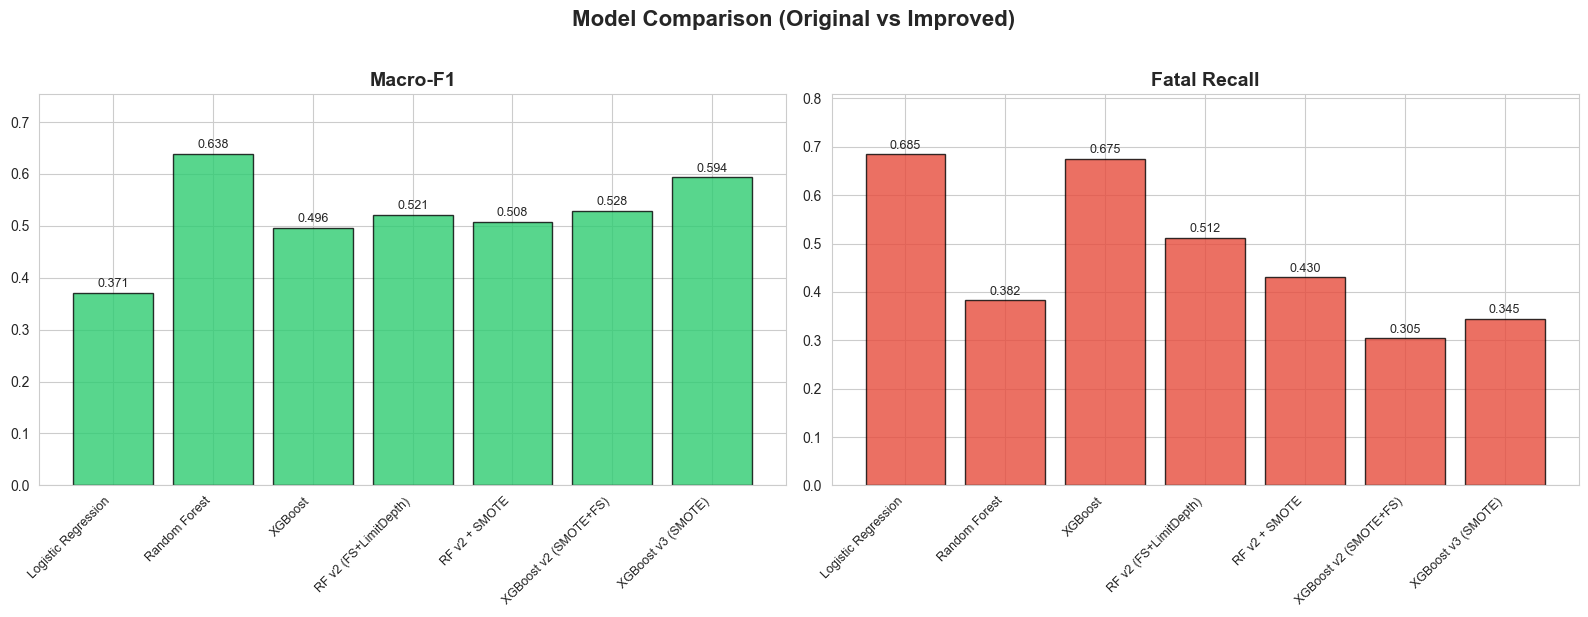

In [ ]:
# Comparison bar chart: Macro-F1 and Fatal Recall for all 6 models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_plot = ['Macro-F1', 'Fatal Recall']
colors_plot = ['#2ecc71', '#e74c3c']

for ax, metric, color in zip(axes, metrics_plot, colors_plot):
    bars = ax.bar(range(len(results_df_v2)), results_df_v2[metric],
                  color=color, edgecolor='black', alpha=0.8)
    for bar, val in zip(bars, results_df_v2[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(results_df_v2)))
    ax.set_xticklabels(results_df_v2.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, max(results_df_v2[metric]) * 1.18)

plt.suptitle('Model Comparison (Original vs Improved)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# RF overfitting comparison
rf_train_f1 = f1_score(y_train, rs_rf.predict(X_train), average='macro')
rf_test_f1 = f1_score(y_test, y_pred_rf, average='macro')

rf_v2_train_f1 = f1_score(y_train, rs_rf_v2.predict(X_train_fs), average='macro')
rf_v2_test_f1 = f1_score(y_test, y_pred_rf_v2, average='macro')

rf_v2s_train_f1 = f1_score(y_train_fs_smote, rs_rf_v2_smote.predict(X_train_fs_smote), average='macro')
rf_v2s_test_f1 = f1_score(y_test, y_pred_rf_v2_smote, average='macro')

print(" RF Overfitting Comparison ")
print(f"RF Original:   Train Macro-F1={rf_train_f1:.4f}, Test={rf_test_f1:.4f}, Gap={rf_train_f1 - rf_test_f1:.4f}")
print(f"RF v2:         Train Macro-F1={rf_v2_train_f1:.4f}, Test={rf_v2_test_f1:.4f}, Gap={rf_v2_train_f1 - rf_v2_test_f1:.4f}")
print(f"RF v2+SMOTE:   Train Macro-F1={rf_v2s_train_f1:.4f}, Test={rf_v2s_test_f1:.4f}, Gap={rf_v2s_train_f1 - rf_v2s_test_f1:.4f}")


 RF Overfitting Comparison 
RF Original:   Train Macro-F1=0.9554, Test=0.6384, Gap=0.3170
RF v2:         Train Macro-F1=0.6667, Test=0.5211, Gap=0.1457
RF v2+SMOTE:   Train Macro-F1=0.8608, Test=0.5077, Gap=0.3531


## Step 4.6: ROC Curves (One-vs-Rest)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['Fatal', 'Serious', 'Slight']

# Collect predict_proba for each model
roc_models = {}

roc_models['Logistic Regression'] = lr.predict_proba(X_test)

roc_models['Random Forest'] = rs_rf.best_estimator_.predict_proba(X_test)

roc_models['XGBoost'] = rs_xgb.best_estimator_.predict_proba(X_test)

roc_models['RF v2'] = rs_rf_v2.best_estimator_.predict_proba(X_test_fs)

roc_models['RF v2 + SMOTE'] = rs_rf_v2_smote.best_estimator_.predict_proba(X_test_fs)

roc_models['XGBoost v2'] = rs_xgb_v2.best_estimator_.predict_proba(X_test_fs)

roc_models['XGBoost v3'] = rs_xgb_v3.best_estimator_.predict_proba(X_test)


print(f"Models with predict_proba: {list(roc_models.keys())}")


Models with predict_proba: ['Logistic Regression', 'Random Forest', 'XGBoost', 'RF v2', 'RF v2 + SMOTE', 'XGBoost v2', 'XGBoost v3']


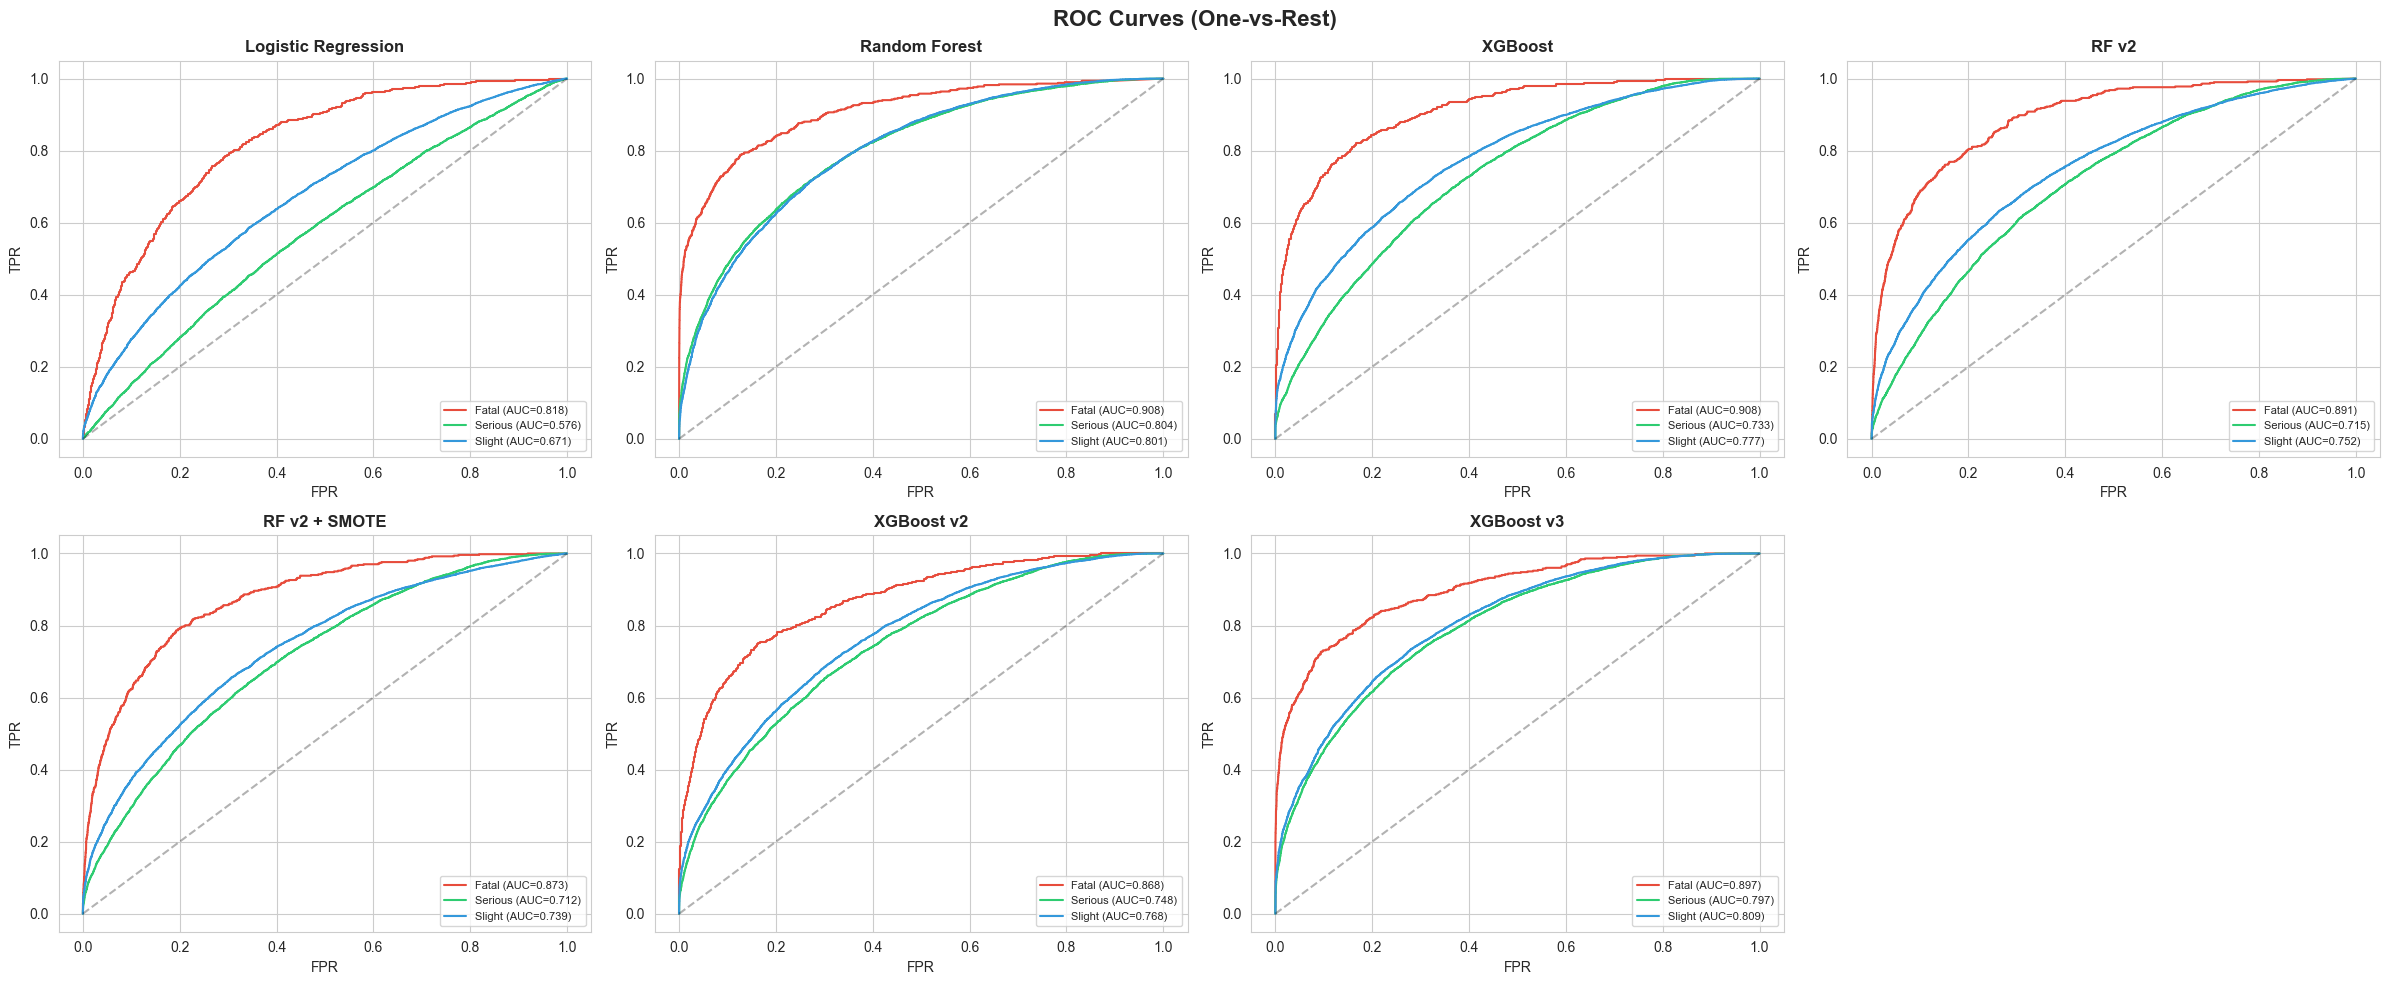

In [ ]:
# Plot ROC curves: 2x3 grid
n_models = len(roc_models)
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

colors_roc = ['#e74c3c', '#2ecc71', '#3498db']

for idx, (name, y_proba) in enumerate(roc_models.items()):
    ax = axes[idx]
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], label=f'{cls} (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8)

for idx in range(n_models, 8):
    axes[idx].set_visible(False)

plt.suptitle('ROC Curves (One-vs-Rest)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# AUC summary table
auc_results = []
for name, y_proba in roc_models.items():
    row = {'Model': name}
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        row[f'{cls} AUC'] = auc(fpr, tpr)
    row['Macro AUC'] = np.mean([row[f'{cls} AUC'] for cls in class_names])
    auc_results.append(row)

auc_df = pd.DataFrame(auc_results).set_index('Model')
print("=== AUC Summary ===")
print(auc_df.round(4).to_string())


=== AUC Summary ===
                     Fatal AUC  Serious AUC  Slight AUC  Macro AUC
Model                                                             
Logistic Regression     0.8176       0.5757      0.6710     0.6881
Random Forest           0.9080       0.8038      0.8009     0.8376
XGBoost                 0.9085       0.7327      0.7773     0.8062
RF v2                   0.8906       0.7145      0.7516     0.7856
RF v2 + SMOTE           0.8732       0.7115      0.7389     0.7745
XGBoost v2              0.8685       0.7477      0.7679     0.7947
XGBoost v3              0.8973       0.7974      0.8092     0.8346


### ROC Analysis
The Serious class proves to be the hardest to classify across all models, consistently achieve the lowest AUC — likely due to its boundary overlap with both Fatal and Slight categories. Random Forest and XGBoost v3 stand out as the better-performing models overall.

## Step 4.7: Retrain best model on full data for feature importance

In [ ]:
# Pick on higher Macro-F1 (RandomForest)
best_name = results_df_v2['Macro-F1'].idxmax()
print(f"Best model by Macro-F1: {best_name}")

best_model = RandomForestClassifier(**rs_rf.best_params_, class_weight='balanced', random_state=42)
best_model.fit(X, y)

print(f"Final model trained on full data: {X.shape[0]:,} samples")


Best model by Macro-F1: Random Forest
Final model trained on full data: 128,266 samples


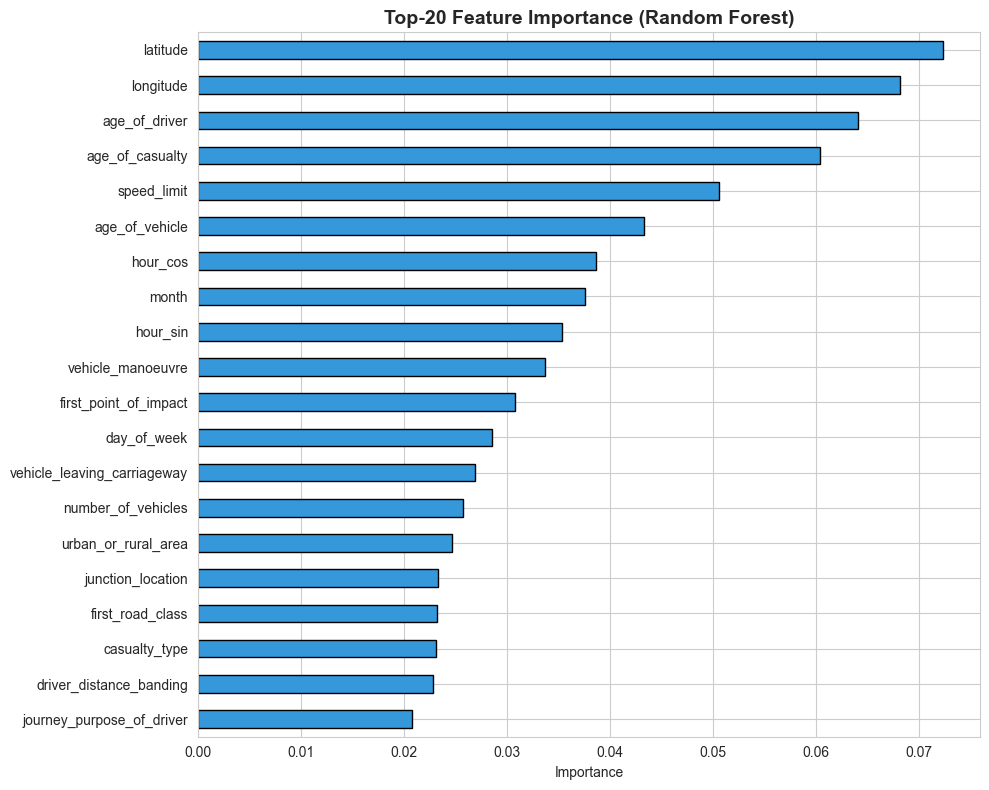


Top-20 features:
   1. latitude                                 0.0723
   2. longitude                                0.0681
   3. age_of_driver                            0.0640
   4. age_of_casualty                          0.0604
   5. speed_limit                              0.0505
   6. age_of_vehicle                           0.0433
   7. hour_cos                                 0.0386
   8. month                                    0.0376
   9. hour_sin                                 0.0354
  10. vehicle_manoeuvre                        0.0337
  11. first_point_of_impact                    0.0307
  12. day_of_week                              0.0285
  13. vehicle_leaving_carriageway              0.0269
  14. number_of_vehicles                       0.0257
  15. urban_or_rural_area                      0.0247
  16. junction_location                        0.0233
  17. first_road_class                         0.0232
  18. casualty_type                            0.0231
  19. driv

In [ ]:
# Feature Importance: top-20 bar chart
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title(f'Top-20 Feature Importance ({best_name})', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop-20 features:")
for i, (feat, imp) in enumerate(top20.items(), 1):
    print(f"  {i:2d}. {feat:40s} {imp:.4f}")

**Note on feature selection for association rule mining:** Although Random Forest achieved the highest Macro-F1, its Gini-based feature importance is biased towards high-cardinality continuous variables (e.g. latitude, longitude, month), which lack actionable meaning for policy recommendations. We therefore use the feature importance from XGBoost to select features for association rule mining, as XGBoost's importance better reflects genuine predictive contribution and yields features with clear physical interpretability — essential for translating rules into actionable road safety insights.

In [ ]:
# Retrain the xgboost model on full data.
xgboost_model = XGBClassifier(**rs_xgb.best_params_, objective='multi:softmax', num_class=3,
                                eval_metric='mlogloss', random_state=42, use_label_encoder=False)
sw_full = compute_sample_weight('balanced', y)
xgboost_model.fit(X, y, sample_weight=sw_full)
print(f"XGBoost trained on full data: {X.shape[0]:,} samples")

XGBoost trained on full data: 128,266 samples


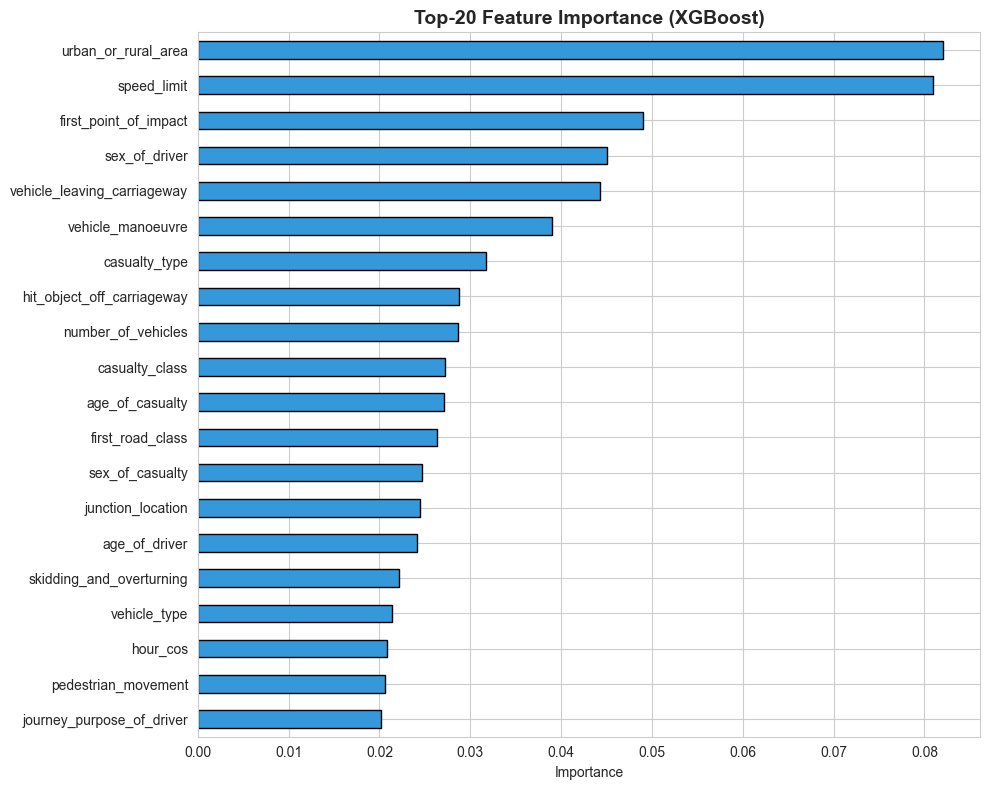

 
Top-20 features:
   1. urban_or_rural_area                      0.0820
   2. speed_limit                              0.0810
   3. first_point_of_impact                    0.0490
   4. sex_of_driver                            0.0451
   5. vehicle_leaving_carriageway              0.0443
   6. vehicle_manoeuvre                        0.0390
   7. casualty_type                            0.0317
   8. hit_object_off_carriageway               0.0287
   9. number_of_vehicles                       0.0287
  10. casualty_class                           0.0273
  11. age_of_casualty                          0.0271
  12. first_road_class                         0.0263
  13. sex_of_casualty                          0.0247
  14. junction_location                        0.0245
  15. age_of_driver                            0.0241
  16. skidding_and_overturning                 0.0222
  17. vehicle_type                             0.0214
  18. hour_cos                                 0.0209
  19. ped

In [ ]:
# Feature Importance(XGBoost): top-20 bar chart
importances = pd.Series(xgboost_model.feature_importances_, index=X.columns)
topk=20
topn = importances.sort_values(ascending=False).head(topk)

fig, ax = plt.subplots(figsize=(10, 8))
topn.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title(f'Top-{topk} Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f" \nTop-{topk} features:")
for i, (feat, imp) in enumerate(topn.items(), 1):
    print(f"  {i:2d}. {feat:40s} {imp:.4f}")

# Step 5: Association Rule Mining

In [ ]:
!pip install mlxtend -q

## 5.1 Get top-25 from XGBoost full-data importance as candidate pool

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Get top-25 from XGBoost full-data importance as candidate pool
arm_candidates = importances.sort_values(ascending=False).head(25).index.tolist()

print("Top-25 candidate features:")
for i, f in enumerate(arm_candidates, 1):
    print(f"  {i:2d}. {f}")

Top-25 candidate features:
   1. urban_or_rural_area
   2. speed_limit
   3. first_point_of_impact
   4. sex_of_driver
   5. vehicle_leaving_carriageway
   6. vehicle_manoeuvre
   7. casualty_type
   8. hit_object_off_carriageway
   9. number_of_vehicles
  10. casualty_class
  11. age_of_casualty
  12. first_road_class
  13. sex_of_casualty
  14. junction_location
  15. age_of_driver
  16. skidding_and_overturning
  17. vehicle_type
  18. hour_cos
  19. pedestrian_movement
  20. journey_purpose_of_driver
  21. road_type
  22. casualty_distance_banding
  23. light_conditions
  24. driver_distance_banding
  25. latitude


## 5.2 Manually select interpretable features from the top-25 pool

In [ ]:
# Manually select interpretable features from the top-25 pool
# Dropped: casualty_type (30 cats, too granular), hour_cos (not interpretable), sex_of_casualty (redundant with sex_of_driver)
arm_features = [
    'urban_or_rural_area',            # 1
    'speed_limit',                    # 2
    'first_point_of_impact',          # 3
    'sex_of_driver',                  # 4
    'vehicle_leaving_carriageway',    # 5
    'vehicle_manoeuvre',              # 6
    'casualty_class',                 # 7  (rank 10, replaces casualty_type)
    'hit_object_off_carriageway',     # 8
    'number_of_vehicles',            # 9
    'age_of_casualty',               # 10
    'first_road_class',              # 11
    'junction_location',             # 12
    'age_of_driver',                 # 13
    'skidding_and_overturning',      # 14 (rank 16)
    'vehicle_type',                  # 15 (rank 17)
    'light_conditions',              # 16 (rank 23)
]

print(f"\nFinal selected {len(arm_features)} features for ARM:")
for i, f in enumerate(arm_features, 1):
    print(f"  {i:2d}. {f}")

# Use final_df_for_ARM (already imputed, no encoding, no scaling)
rule_df = final_df_for_ARM[arm_features + ['collision_severity']].copy()
print(f"\nrule_df shape: {rule_df.shape}")
print(f"Missing values: {rule_df.isnull().sum().sum()}")


Final selected 16 features for ARM:
   1. urban_or_rural_area
   2. speed_limit
   3. first_point_of_impact
   4. sex_of_driver
   5. vehicle_leaving_carriageway
   6. vehicle_manoeuvre
   7. casualty_class
   8. hit_object_off_carriageway
   9. number_of_vehicles
  10. age_of_casualty
  11. first_road_class
  12. junction_location
  13. age_of_driver
  14. skidding_and_overturning
  15. vehicle_type
  16. light_conditions

rule_df shape: (128266, 17)
Missing values: 0


## 5.3 Binary Feature Engineering

Converting raw features into binary (0/1) format required for Association Rule Mining:

- **speed_limit**: speed ≥ 60mph → `speed_limit_high`
- **light_conditions**: darkness conditions (codes 4/5/6/7) → `light_conditions_dark`
- **urban_or_rural_area**: rural area (code 2) → `urban_or_rural_area_rural`
- **casualty_class**: split into three independent binary columns — driver / passenger / pedestrian like one-hot code
- **Numeric features**: binarised using median as threshold; above median = 1
- **Categorical features**: categories with Fatal+Serious rate above the overall mean are flagged as high-risk (1)

Target variable `is_fatal_or_serious`: set to 1 when collision_severity is 1 (Fatal) or 2 (Serious).

## Print each binary column with the percentage of records flagged as high-risk (value = 1)

In [ ]:
binary_df = pd.DataFrame()

# Overall Fatal+Serious rate for threshold
overall_fs_rate = rule_df['collision_severity'].isin([1, 2]).mean()
print(f"Overall Fatal+Serious rate: {overall_fs_rate*100:.2f}%")

for feat in arm_features:
    col_data = rule_df[feat]

    # special
    if feat == 'speed_limit':
        binary_df[f'{feat}_high'] = (col_data >= 60).astype(int)

    elif feat == 'light_conditions':
        # 4=Dark-lit, 5=Dark-unlit, 6=Dark-no light, 7=Darkness-unknown
        binary_df[f'{feat}_dark'] = col_data.isin([4, 5, 6, 7, '4', '5', '6', '7']).astype(int)

    elif feat == 'urban_or_rural_area':
        binary_df[f'{feat}_rural'] = col_data.isin([2, '2']).astype(int)

    elif feat == 'casualty_class':
        # Split into 3 interpretable binary columns
        binary_df['casualty_is_driver']     = col_data.isin([1, '1']).astype(int)
        binary_df['casualty_is_passenger']  = col_data.isin([2, '2']).astype(int)
        binary_df['casualty_is_pedestrian'] = col_data.isin([3, '3']).astype(int)

    # deal numeric
    elif pd.api.types.is_numeric_dtype(col_data):
        median_val = col_data.median()
        binary_df[f'{feat}_above_med'] = (col_data > median_val).astype(int)

    # deal categorical
    else:
        temp = rule_df[[feat, 'collision_severity']].copy()
        temp['is_fs'] = temp['collision_severity'].isin([1, 2]).astype(int)
        cat_rates = temp.groupby(feat)['is_fs'].mean()
        high_risk_cats = cat_rates[cat_rates > overall_fs_rate].index.tolist()
        binary_df[f'{feat}_high_risk'] = col_data.isin(high_risk_cats).astype(int)

# Add target
binary_df['is_fatal_or_serious'] = rule_df['collision_severity'].isin([1, 2]).astype(int)

print(f"Binary DataFrame shape: {binary_df.shape}")
print(f"\nBinary columns:")


max_len = max(len(col) for col in binary_df.columns)
for i,col in enumerate(binary_df.columns,1):
    print(f"  {i:2d}. {col:<{max_len}}  {binary_df[col].mean()*100:6.2f}%")

Overall Fatal+Serious rate: 26.96%
Binary DataFrame shape: (128266, 19)

Binary columns:
   1. urban_or_rural_area_rural               37.13%
   2. speed_limit_high                        20.97%
   3. first_point_of_impact_high_risk         53.83%
   4. sex_of_driver_high_risk                 65.54%
   5. vehicle_leaving_carriageway_high_risk   15.83%
   6. vehicle_manoeuvre_high_risk             63.36%
   7. casualty_is_driver                      65.68%
   8. casualty_is_passenger                   19.37%
   9. casualty_is_pedestrian                  14.95%
  10. hit_object_off_carriageway_high_risk    91.73%
  11. number_of_vehicles_above_med            11.40%
  12. age_of_casualty_above_med               48.57%
  13. first_road_class_high_risk              57.80%
  14. junction_location_high_risk             53.17%
  15. age_of_driver_above_med                 47.07%
  16. skidding_and_overturning_high_risk      15.09%
  17. vehicle_type_high_risk                  14.24%
  18. ligh

## 5.4 Association Rule Mining — Target Rule Extraction

This section performs **Association Rule Mining (ARM)** using the Apriori algorithm
to identify feature combinations associated with fatal or serious outcomes.

In [ ]:
# Run Apriori
binary_df_bool = binary_df.astype(bool)
frequent_items = apriori(binary_df_bool, min_support=0.01, use_colnames=True)
print(f"Frequent itemsets: {len(frequent_items)}")

# Generate rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1.0)

# Filter: results must contain is_fatal_or_serious
target_rules = rules[rules['consequents'] == frozenset(['is_fatal_or_serious'])]
target_rules_by_lift = target_rules.sort_values('lift', ascending=False)

print(f"Rules with is_fatal_or_serious as consequent: {len(target_rules)}")


Frequent itemsets: 18130
Rules with is_fatal_or_serious as consequent: 5348


In [ ]:
# Top-10 by lift
top10 = target_rules_by_lift.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
top10['antecedents'] = top10['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top10['consequents'] = top10['consequents'].apply(lambda x: ', '.join(sorted(x)))
top10 = top10.reset_index(drop=True)
top10.index = top10.index + 1

print("Top-10 Association Rules (by Lift):")
print(top10.to_string())

Top-10 Association Rules (by Lift):
                                                                                                                                                                                                   antecedents          consequents   support  confidence      lift
1                                                                                 first_road_class_high_risk, speed_limit_high, urban_or_rural_area_rural, vehicle_manoeuvre_high_risk, vehicle_type_high_risk  is_fatal_or_serious  0.010034    0.581563  2.157229
2                                                                                                       first_point_of_impact_high_risk, speed_limit_high, vehicle_manoeuvre_high_risk, vehicle_type_high_risk  is_fatal_or_serious  0.010315    0.578993  2.147696
3                                                                                                            first_road_class_high_risk, speed_limit_high, vehicle_manoeuvre_high_risk, 

### 5.5 Antecedent Frequency Analysis (Top-10 Rules)
This cell counts how many of those 10 rules each feature appears in — revealing
which features are the **most consistent predictors** of fatal or serious outcomes.

In [ ]:
ant_counter = {}
for ant_str in top10['antecedents']:
    for item in ant_str.split(', '):
        ant_counter[item] = ant_counter.get(item, 0) + 1

for item, count in sorted(ant_counter.items(), key=lambda x: x[1], reverse=True):
    print(f"  {item:<50s} {count}/10")

  vehicle_type_high_risk                             10/10
  urban_or_rural_area_rural                          8/10
  first_point_of_impact_high_risk                    8/10
  vehicle_manoeuvre_high_risk                        7/10
  first_road_class_high_risk                         6/10
  speed_limit_high                                   6/10
  hit_object_off_carriageway_high_risk               3/10
  sex_of_driver_high_risk                            3/10


### 5.6 Vehicle Type Risk Analysis

Calculates the fatal-or-serious (F+S) rate per vehicle type and identifies
which types exceed the overall dataset average — forming the basis for the
`vehicle_type_high_risk` binary feature used in ARM.

In [ ]:
vehicle_type_labels = {
    '1': 'Pedal cycle', '2': 'Motorcycle 50cc and under', '3': 'Motorcycle 125cc and under',
    '4': 'Motorcycle over 125cc and up to 500cc', '5': 'Motorcycle over 500cc',
    '8': 'Taxi/Private hire car', '9': 'Car', '10': 'Minibus (8-16 seats)',
    '11': 'Bus or coach (17+ seats)', '16': 'Ridden horse', '17': 'Agricultural vehicle',
    '18': 'Tram', '19': 'Van/Goods ≤3.5t', '20': 'Goods 3.5-7.5t', '21': 'Goods ≥7.5t',
    '22': 'Mobility scooter', '23': 'Electric motorcycle', '90': 'Other vehicle',
    '97': 'Motorcycle - unknown cc', '98': 'Goods - unknown weight',
    '99': 'Unknown (self rep)', '103': 'Motorcycle Scooter (1979-1998)',
    '104': 'Motorcycle (1979-1998)', '105': 'Motorcycle Combination (1979-1998)',
    '106': 'Motorcycle over 125cc (1999-2004)', '108': 'Taxi (1979-2004)',
    '109': 'Car (1979-2004)', '110': 'Minibus/Caravan (1979-1998)', '113': 'Goods >3.5t (1979-1998)',
}

temp = rule_df[['vehicle_type', 'collision_severity']].copy()
temp['is_fs'] = temp['collision_severity'].isin([1, 2]).astype(int)
cat_rates = temp.groupby('vehicle_type')['is_fs'].mean().sort_values(ascending=False)
cat_counts = temp.groupby('vehicle_type')['is_fs'].count()


print(f"Overall Fatal+Serious rate: {overall_fs_rate*100:.2f}%\n")
print(f"High-risk vehicle types (above {overall_fs_rate*100:.2f}%):")
print("-" * 75)
for cat, rate in cat_rates.items():
    if rate > overall_fs_rate:
        label = vehicle_type_labels.get(str(cat), 'Unknown')
        n = cat_counts[cat]
        print(f"  Code {str(cat):<5s}  {rate*100:6.2f}%   n={n:<6d}  {label}")

Overall Fatal+Serious rate: 26.96%

High-risk vehicle types (above 26.96%):
---------------------------------------------------------------------------
  Code 18      54.55%   n=11      Tram
  Code 5       54.17%   n=4536    Motorcycle over 500cc
  Code 23      47.52%   n=423     Electric motorcycle
  Code 97      47.23%   n=506     Motorcycle - unknown cc
  Code 21      44.22%   n=545     Goods ≥7.5t
  Code 17      42.70%   n=89      Agricultural vehicle
  Code 10      42.48%   n=266     Minibus (8-16 seats)
  Code 16      41.43%   n=70      Ridden horse
  Code 4       40.63%   n=1890    Motorcycle over 125cc and up to 500cc
  Code 90      36.32%   n=680     Other vehicle
  Code 20      34.36%   n=291     Goods 3.5-7.5t
  Code 22      29.52%   n=315     Mobility scooter
  Code 2       29.38%   n=817     Motorcycle 50cc and under
  Code 11      28.45%   n=2946    Bus or coach (17+ seats)
  Code 19      27.17%   n=4877    Van/Goods ≤3.5t


### 5.7 Vehicle Manoeuvre Risk Analysis

Calculates the fatal-or-serious (F+S) rate per vehicle manoeuvre and identifies
which types exceed the overall dataset average

In [ ]:
vehicle_manoeuvre_labels = {
    '1': 'Reversing', '2': 'Parked', '3': 'Waiting to go ahead',
    '4': 'Slowing or stopping', '5': 'Moving off', '6': 'U-turn',
    '7': 'Turning left', '8': 'Waiting to turn left', '9': 'Turning right',
    '10': 'Waiting to turn right', '11': 'Changing lane to left',
    '12': 'Changing lane to right', '13': 'Overtaking moving vehicle on its offside',
    '14': 'Overtaking stationary vehicle on its offside',
    '15': 'Overtaking on nearside', '19': 'Going ahead',
    '20': 'Parking', '99': 'Unknown (self reported)',
}

temp = rule_df[['vehicle_manoeuvre', 'collision_severity']].copy()
temp['is_fs'] = temp['collision_severity'].isin([1, 2]).astype(int)
cat_rates = temp.groupby('vehicle_manoeuvre')['is_fs'].mean().sort_values(ascending=False)
cat_counts = temp.groupby('vehicle_manoeuvre')['is_fs'].count()

print(f"Overall Fatal+Serious rate: {overall_fs_rate*100:.2f}%\n")
print(f"High-risk vehicle manoeuvres (above {overall_fs_rate*100:.2f}%):")
print("-" * 75)
for cat, rate in cat_rates.items():
    if rate > overall_fs_rate:
        label = vehicle_manoeuvre_labels.get(str(cat), 'Unknown')
        n = cat_counts[cat]
        print(f"  Code {str(cat):<5s}  {rate*100:6.2f}%   n={n:<6d}  {label}")

Overall Fatal+Serious Rate: 26.96%

High-risk vehicle manoeuvres (above 26.96%):

| Code | Description | Fatal+Serious Rate | Sample Size |
|------|-------------|--------------------|-------------|
| 13 | Overtaking moving vehicle on its offside | 43.88% | 2,270 |
| 19 | Going ahead | 31.89% | 74,817 |
| 12 | Changing lane to right | 31.20% | 843 |
| 15 | Overtaking on nearside | 30.93% | 931 |
| 14 | Overtaking stationary vehicle on its offside | 30.72% | 1,328 |
| 6 | U-turn | 28.91% | 467 |
| 11 | Changing lane to left | 26.98% | 619 |

## Summary of Association Rule Mining Findings
The top-10 association rules by lift consistently identify a core high-risk scenario for Fatal/Serious collisions. `vehicle_type_high_risk` is the only antecedent appearing in all 10 rules, making it the single strongest predictor. Disaggregating the high-risk vehicle types reveals that motorcycles dominate: Motorcycle over 500cc has a 54.2% Fatal/Serious rate (n=4,536), followed by Electric motorcycle at 47.5% (n=423) and Motorcycle 125–500cc at 40.6% (n=1,890). Heavy goods vehicles (≥7.5t) also stand out at 44.2% (n=545), likely due to the severity of impact in collisions involving large mass differentials. Categories such as Tram (54.5%, n=11) and Ridden horse (41.4%, n=70) show elevated rates but are too small in sample size to draw reliable conclusions.

Beyond vehicle type, `urban_or_rural_area_rural` and `first_point_of_impact_high_risk` each appear in 8/10 rules, `vehicle_manoeuvre_high_risk` in 7/10, and `first_road_class_high_risk` and `speed_limit_high` each in 6/10. Together these factors paint a clear picture: **motorcycles and heavy vehicles performing risky manoeuvres on high-speed rural roads face the highest severity risk**. Under these combined conditions, the probability of a Fatal/Serious outcome reaches 55–58% — approximately double the baseline rate of 27% (lift ≈ 2.1).